# Dynamic Subnetwork Prediction and Generalization

This notebook explores different approaches to dynamic subnetwork prediction and generalization, focusing on the Digits dataset. It covers:

1.  **Iterated Masking with Depth-Specific Scores**: A baseline approach where masks are learned independently for each 'virtual' depth.
2.  **Mask Vocabulary + Routing**: Introduces a vocabulary of learned masks and a router to select which mask to apply at each step.
3.  **Transformer over a Fixed Random Vocabulary of Masks**: Uses a Transformer to generate sequences of mask tokens from a fixed, random vocabulary.
4.  **Learned-Mask Transformer Program Model**: Extends the Transformer approach with a learned mask vocabulary, context-dependent policy, and regularization for mask diversity.
5.  **Transformer Program Model with Frozen Interfaces**: Integrates pre-trained input autoencoders and output readouts to train the program model in a 'thought space'.

## Setup and Common Utilities

This section consolidates all necessary imports, device configurations, random seeds, and common helper functions used throughout the notebook to avoid redundancy.

In [1]:
import copy
import random
import math
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torchvision.transforms import v2



# ============================================================
# Global Configuration
# ============================================================
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using {device} device")

Using cuda device


In [2]:
# ============================================================
# Core Network Components (from original cell S5Y9TN2K2w_b)
# ============================================================

class ClassicNetwork(nn.Module):
    def __init__(self, layer_sizes,bias=True):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            *[z for l in layer_sizes
              for z in [nn.Linear(l[0], l[1],bias=bias), nn.ReLU()]][:-1]
        )
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

# Set up signed Kaiming initialization.
def signed_kaiming_constant_(tensor, a=0, mode='fan_in', nonlinearity='relu', k=0.5, sparsity=0):
    fan = nn.init._calculate_correct_fan(tensor, mode)  # calculating correct fan, depends on shape and type of nn
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = (gain / math.sqrt(fan))
    # scale by (1/sqrt(k))
    if k != 0:
        std *= (1 / math.sqrt(k))
    with torch.no_grad():
        tensor.uniform_(-std, std)
        return tensor

# A function to retreive a subset of the top k% of the weights by their score.
# The gradient is estimated by the identity (i.e. it goes "straight-through").
# See the paper "What's Hidden in a Randomly Weighted Neural Network?" for
# more details (https://arxiv.org/abs/1911.13299)
# (this code adapted from https://github.com/iceychris/edge-popup)
class GetSubnet(autograd.Function):
    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Get the subnetwork by sorting the scores and using the top k%
        out = scores.clone()
        _, idx = scores.flatten().sort()
        j = int((1-k) * scores.numel())
        # flat_out and out access the same memory.
        flat_out = out.flatten()
        flat_out[idx[:j]] = 0
        flat_out[idx[j:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # send the gradient g straight-through on the backward pass.
        return grad, None

class LinearSubnet(nn.Linear):
    def __init__(self, in_features, out_features, init=signed_kaiming_constant_, k=0.5, **kwargs):
        super().__init__(in_features, out_features, **kwargs)
        self.scores = nn.Parameter(torch.randn(out_features,2*in_features))
        init(self.weight)
        self.weight.requires_grad_(False)
        self.scores.requires_grad_(True)
        if self.bias is not None:
          self.bias_scores = nn.Parameter(torch.randn(2,out_features))
          self.bias.requires_grad_(False)
          self.bias_scores.requires_grad_(True)
        self.k=k
    def forward(self, x):
        mask = GetSubnet.apply(self.scores.abs(),self.k)
        weight = self.weight * mask[:, :self.weight.shape[-1]]
        if self.bias is not None:
          bias_mask = GetSubnet.apply(self.bias_scores.abs(),self.k)
          bias = self.bias * bias_mask[0,:self.bias.shape[-1]]
          return F.linear(x, weight, bias)
        return F.linear(x,weight)

class Network(nn.Module):
    def __init__(self, layer_sizes, init=signed_kaiming_constant_, bias=True, double=True, extra_capacity=0):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
                *[z for i,l in enumerate(layer_sizes)
                  for z in [LinearSubnet(l[0], l[1],bias=bias), nn.ReLU()]][:-1]
            )
    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

In [3]:
# ============================================================
# General Utility Functions
# ============================================================

def smooth(x, k=5):
    """Applies a moving average filter to smooth a 1D array."""
    x = np.asarray(x, dtype=float)
    if len(x) < k:
        return x
    return np.convolve(x, np.ones(k) / k, mode='valid')

def jaccard(A, B):
    """Calculates the Jaccard overlap between two binary masks."""
    A = A > 0.5
    B = B > 0.5
    inter = np.logical_and(A, B).sum()
    union = np.logical_or(A, B).sum()
    if union == 0:
        return 1.0  # If both sets are empty, consider overlap 100%
    return inter / union

def empirical_entropy(counts, eps=1e-12):
    """Calculates the empirical entropy of a count distribution."""
    counts = np.asarray(counts, dtype=float)
    s = counts.sum()
    if s <= 0:
        return 0.0
    p = counts / s
    return float(-(p * np.log(p + eps)).sum())

def count_parameters(model):
    """Counts total, trainable, and frozen parameters in a PyTorch model."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    return total, trainable, frozen

def token_sequence_to_string(seq, num_masks, start_id, end_id):
    """Converts a sequence of token IDs to a human-readable string."""
    pieces = []
    for t in seq:
        if t == start_id:
            pieces.append("<START>")
        elif t == end_id:
            pieces.append("<END>")
        else:
            pieces.append(f"M{t}")
    return " ".join(pieces)

def straight_through_gumbel_one_hot(logits, tau=1.0, eps=1e-20):
    """Applies Gumbel-softmax with straight-through gradient estimation."""
    g = -torch.log(-torch.log(torch.rand_like(logits) + eps) + eps)
    probs = torch.softmax((logits + g) / tau, dim=-1)
    idx = probs.argmax(dim=-1)
    y_hard = F.one_hot(idx, num_classes=logits.shape[-1]).float()
    y = y_hard.detach() - probs.detach() + probs
    return y, idx, probs

## Dataset Loading and Preprocessing

This section handles the loading, splitting, and scaling of the Digits dataset, preparing it for use in all subsequent experiments.

In [4]:
# ============================================================
# Dataset: sklearn digits
# ============================================================
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

batch_size = 128
train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_ds   = TensorDataset(torch.tensor(X_val),   torch.tensor(y_val))
test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

# Code for first figure in Section 5.11: Dynamic Subnetwork Prediction and Generalization

In [5]:
!nvidia-smi

Tue Apr 21 23:23:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   31C    P0             47W /  600W |       3MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [6]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torchvision.transforms import v2
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import random
import torch.autograd as autograd
import math
from matplotlib import pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor



device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using {device} device")
class ClassicNetwork(nn.Module):
    def __init__(self, layer_sizes,bias=True):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            *[z for l in layer_sizes
              for z in [nn.Linear(l[0], l[1],bias=bias), nn.ReLU()]][:-1]
        )
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

# Set up signed Kaiming initialization.
def signed_kaiming_constant_(tensor, a=0, mode='fan_in', nonlinearity='relu', k=0.5, sparsity=0):
    fan = nn.init._calculate_correct_fan(tensor, mode)  # calculating correct fan, depends on shape and type of nn
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = (gain / math.sqrt(fan))
    # scale by (1/sqrt(k))
    if k != 0:
        std *= (1 / math.sqrt(k))
    with torch.no_grad():
        tensor.uniform_(-std, std)
        return tensor

# A function to retreive a subset of the top k% of the weights by their score.
# The gradient is estimated by the identity (i.e. it goes "straight-through").
# See the paper "What's Hidden in a Randomly Weighted Neural Network?" for
# more details (https://arxiv.org/abs/1911.13299)
# (this code adapted from https://github.com/iceychris/edge-popup)
class GetSubnet(autograd.Function):
    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Get the subnetwork by sorting the scores and using the top k%
        out = scores.clone()
        _, idx = scores.flatten().sort()
        j = int((1-k) * scores.numel())
        # flat_out and out access the same memory.
        flat_out = out.flatten()
        flat_out[idx[:j]] = 0
        flat_out[idx[j:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # send the gradient g straight-through on the backward pass.
        return grad, None

class LinearSubnet(nn.Linear):
    def __init__(self, in_features, out_features, init=signed_kaiming_constant_, k=0.5, **kwargs):
        super().__init__(in_features, out_features, **kwargs)
        self.scores = nn.Parameter(torch.randn(out_features,2*in_features))
        init(self.weight)
        self.weight.requires_grad_(False)
        self.scores.requires_grad_(True)
        if self.bias is not None:
          self.bias_scores = nn.Parameter(torch.randn(2,out_features))
          self.bias.requires_grad_(False)
          self.bias_scores.requires_grad_(True)
        self.k=k
    def forward(self, x):
        mask = GetSubnet.apply(self.scores.abs(),self.k)
        weight = self.weight * mask[:, :self.weight.shape[-1]]
        if self.bias is not None:
          bias_mask = GetSubnet.apply(self.bias_scores.abs(),self.k)
          bias = self.bias * bias_mask[0,:self.bias.shape[-1]]
          return F.linear(x, weight, bias)
        return F.linear(x,weight)

class Network(nn.Module):
    def __init__(self, layer_sizes, init=signed_kaiming_constant_, bias=True, double=True, extra_capacity=0):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
                *[z for i,l in enumerate(layer_sizes)
                  for z in [LinearSubnet(l[0], l[1],bias=bias), nn.ReLU()]][:-1]
            )
    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

Using cuda device


device: cuda

================ Dense baseline ================

dense params: total=26122, trainable=26122, frozen=0
epoch 001 | train loss 2.1719 | train acc 0.4883 | val loss 1.9956 | val acc 0.7326
epoch 010 | train loss 0.1211 | train acc 0.9791 | val loss 0.1843 | val acc 0.9479
epoch 020 | train loss 0.0276 | train acc 0.9974 | val loss 0.1525 | val acc 0.9722
epoch 030 | train loss 0.0103 | train acc 1.0000 | val loss 0.1412 | val acc 0.9722
epoch 040 | train loss 0.0053 | train acc 1.0000 | val loss 0.1422 | val acc 0.9757
epoch 050 | train loss 0.0033 | train acc 1.0000 | val loss 0.1431 | val acc 0.9757
epoch 060 | train loss 0.0023 | train acc 1.0000 | val loss 0.1429 | val acc 0.9757
epoch 070 | train loss 0.0018 | train acc 1.0000 | val loss 0.1428 | val acc 0.9757
epoch 080 | train loss 0.0014 | train acc 1.0000 | val loss 0.1402 | val acc 0.9757
dense test acc = 0.9778


================ Iterated masking with depth-specific scores T=1 ================

T=1: total=59146, 

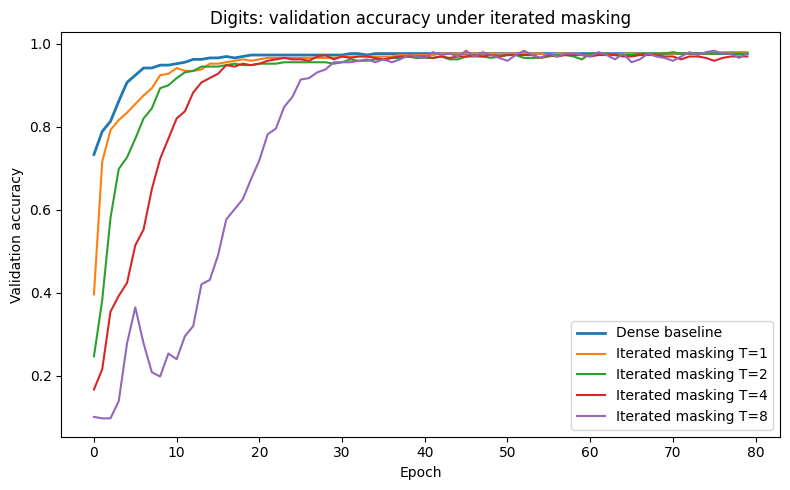

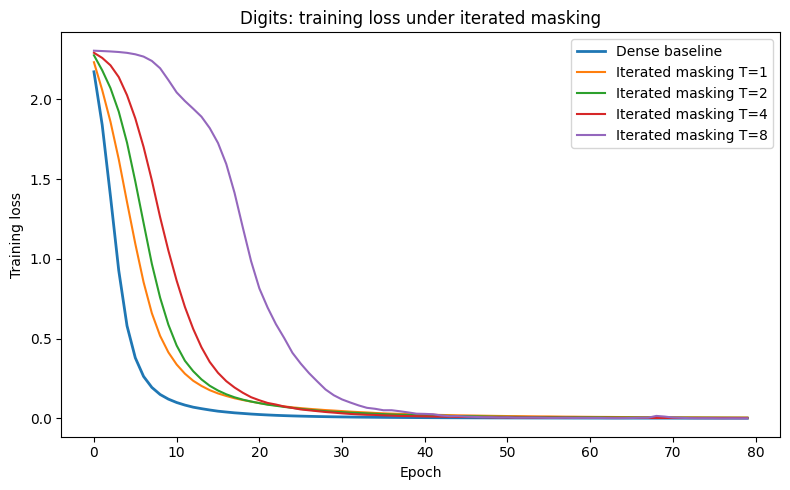

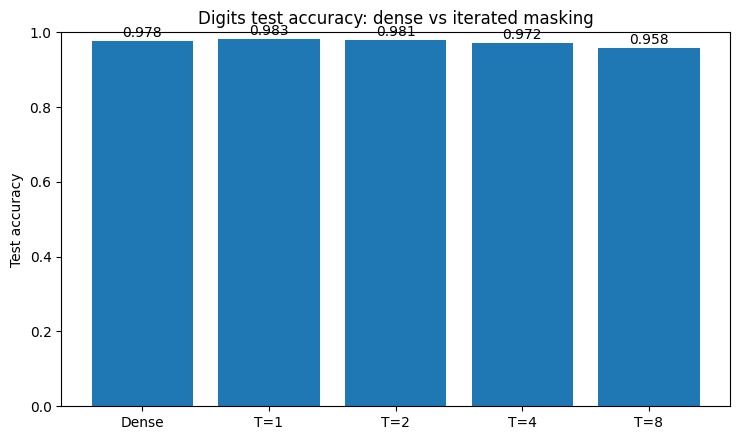


Best iterated-masking depth by validation accuracy: T=8


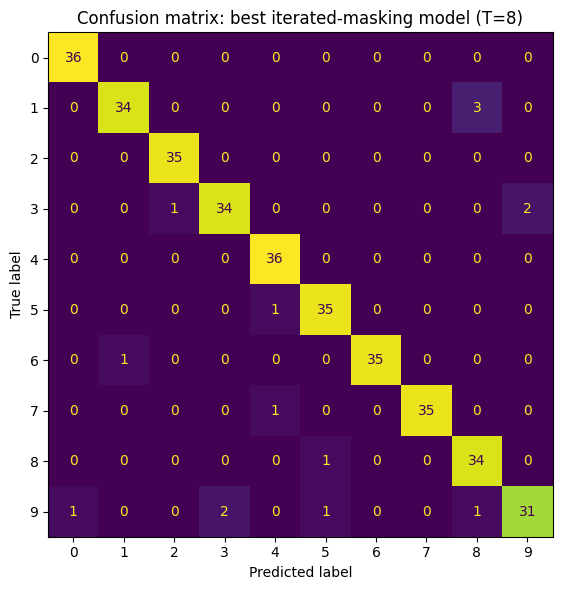

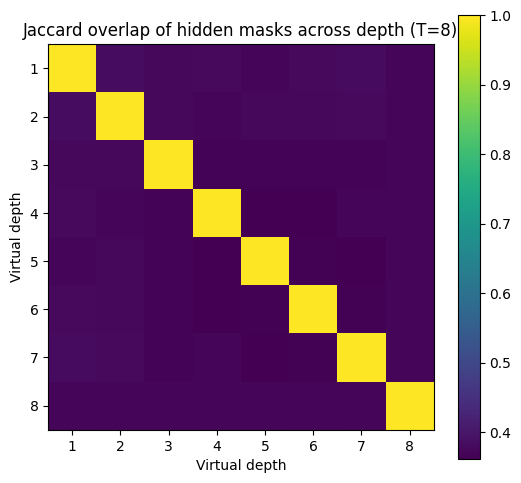

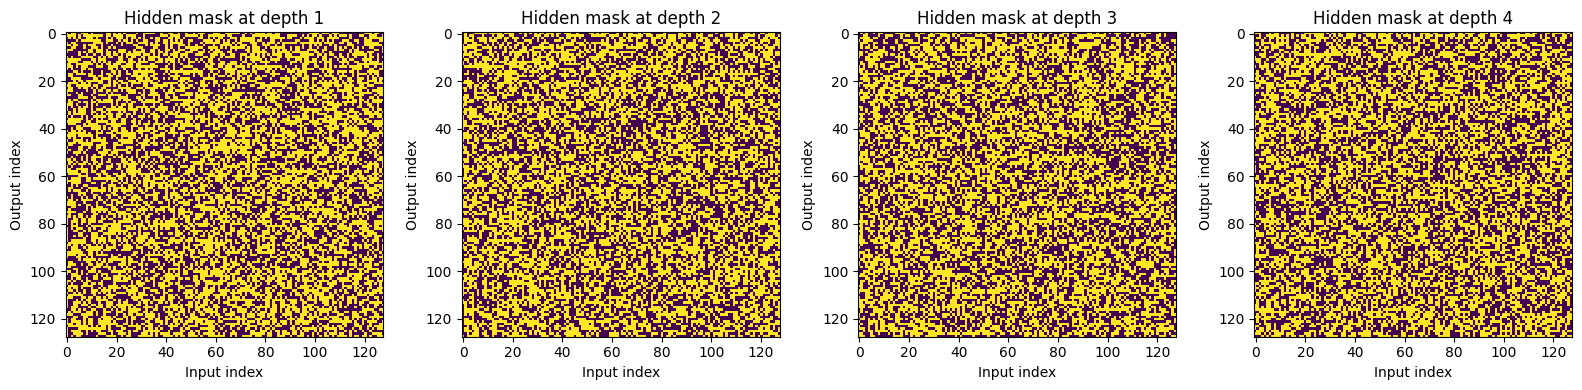

AttributeError: 'Linear' object has no attribute 'scores'

In [7]:
# ============================================================
# Naive implicit-depth experiment with:
#   - shared hidden WEIGHT matrix
#   - different DOUBLED score tensors at each virtual depth
#
# Assumes the following are already defined in a previous cell:
#   - signed_kaiming_constant_
#   - GetSubnet
#   - LinearSubnet
#   - Network
# ============================================================

import copy
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# Reproducibility / device
# ============================================================
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print("device:", device)


# ============================================================
# Dataset: sklearn digits
# ============================================================
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_ds   = TensorDataset(torch.tensor(X_val),   torch.tensor(y_val))
test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)


# ============================================================
# Shared-weight, depth-specific-score hidden layer
# ============================================================
class SharedWeightMultiScoreSubnet(nn.Module):
    """
    Hidden square layer with:
      - one shared frozen weight matrix W
      - one shared frozen bias vector b
      - different doubled score tensors at each virtual depth

    This preserves YOUR double-scoring mechanism exactly:
      each depth t has scores of shape [out_features, 2*in_features]
      and the mask is the first half after top-k on the doubled tensor.
    """
    def __init__(self, features, depth, init=signed_kaiming_constant_, k=0.5, bias=True):
        super().__init__()
        self.features = features
        self.depth = depth
        self.k = k

        # shared frozen hidden weight / bias
        self.weight = nn.Parameter(torch.empty(features, features))
        init(self.weight)
        self.weight.requires_grad_(False)

        if bias:
            self.bias = nn.Parameter(torch.empty(features))
            nn.init.uniform_(self.bias, -0.1, 0.1)
            self.bias.requires_grad_(False)
        else:
            self.register_parameter("bias", None)

        # one doubled score tensor per virtual depth
        self.scores = nn.ParameterList([
            nn.Parameter(torch.randn(features, 2 * features))
            for _ in range(depth)
        ])

        if bias:
            self.bias_scores = nn.ParameterList([
                nn.Parameter(torch.randn(2, features))
                for _ in range(depth)
            ])

    def forward_at_depth(self, x, t):
        mask = GetSubnet.apply(self.scores[t].abs(), self.k)
        weight = self.weight * mask[:, :self.weight.shape[-1]]

        if self.bias is not None:
            bias_mask = GetSubnet.apply(self.bias_scores[t].abs(), self.k)
            bias = self.bias * bias_mask[0, :self.bias.shape[-1]]
            return F.linear(x, weight, bias)

        return F.linear(x, weight)

    @torch.no_grad()
    def weight_mask_at_depth(self, t):
        mask = GetSubnet.apply(self.scores[t].abs(), self.k)
        return mask[:, :self.weight.shape[-1]].detach().cpu().numpy()

    @torch.no_grad()
    def bias_mask_at_depth(self, t):
        if self.bias is None:
            return None
        bias_mask = GetSubnet.apply(self.bias_scores[t].abs(), self.k)
        return bias_mask[0, :self.bias.shape[-1]].detach().cpu().numpy()


# ============================================================
# Iterated masking model
# ============================================================
class IteratedMaskMultiScoreNetwork(nn.Module):
    """
    Architecture:
        x -> input LinearSubnet -> ReLU
          -> shared hidden weight matrix, but depth-specific doubled score tensors
             applied T times with ReLU
          -> output LinearSubnet
    """
    def __init__(self, in_size=64, hidden_size=128, out_size=10, depth=1, bias=True, k=0.5):
        super().__init__()
        self.flatten = nn.Flatten()
        self.depth = depth
        self.act = nn.ReLU()

        # keep using YOUR exact double-scored LinearSubnet here
        self.in_layer = nn.Linear(in_size, hidden_size, bias=bias)
        self.shared_hidden = SharedWeightMultiScoreSubnet(
            features=hidden_size,
            depth=depth,
            bias=bias,
            k=k
        )
        self.out_layer = nn.Linear(hidden_size, out_size, bias=bias)

    def forward(self, x):
        x = self.flatten(x)
        h = self.act(self.in_layer(x))
        for t in range(self.depth):
            h = self.act(self.shared_hidden.forward_at_depth(h, t))
        y = self.out_layer(h)
        return y


class DenseBaseline(nn.Module):
    def __init__(self, in_size=64, hidden_size=128, out_size=10, depth=2, bias=True):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(in_size, hidden_size, bias=bias), nn.ReLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_size, hidden_size, bias=bias), nn.ReLU()]
        layers += [nn.Linear(hidden_size, out_size, bias=bias)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ============================================================
# Helpers
# ============================================================
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    return total, trainable, frozen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_n += xb.size(0)

    return total_loss / total_n, total_correct / total_n


def train_model(model, train_loader, val_loader, epochs=80, lr=1e-3, weight_decay=1e-4, verbose=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=weight_decay
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_state = None
    best_val_acc = -1.0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_n = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_n += xb.size(0)

        train_loss = total_loss / total_n
        train_acc = total_correct / total_n
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        if verbose and (epoch == 1 or epoch % 10 == 0 or epoch == epochs):
            print(
                f"epoch {epoch:03d} | "
                f"train loss {train_loss:.4f} | train acc {train_acc:.4f} | "
                f"val loss {val_loss:.4f} | val acc {val_acc:.4f}"
            )

    model.load_state_dict(best_state)
    return model, history, best_val_acc


@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    ys = []
    yhs = []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        ys.append(yb.numpy())
        yhs.append(preds)
    return np.concatenate(ys), np.concatenate(yhs)


@torch.no_grad()
def get_weight_mask_from_linearsubnet(layer):
    mask = GetSubnet.apply(layer.scores.abs(), layer.k)
    return mask[:, :layer.weight.shape[-1]].detach().cpu().numpy()


def jaccard_overlap(A, B):
    A = A > 0.5
    B = B > 0.5
    inter = np.logical_and(A, B).sum()
    union = np.logical_or(A, B).sum()
    if union == 0:
        return 1.0
    return inter / union


def depth_overlap_matrix(shared_hidden_layer):
    T = shared_hidden_layer.depth
    M = np.zeros((T, T), dtype=np.float32)
    masks = [shared_hidden_layer.weight_mask_at_depth(t) for t in range(T)]
    for i in range(T):
        for j in range(T):
            M[i, j] = jaccard_overlap(masks[i], masks[j])
    return M, masks


# ============================================================
# Run experiments
# ============================================================
epochs = 80
hidden_size = 128
k = 0.5
depths_to_test = [1, 2, 4, 8]

results = {}

print("\n================ Dense baseline ================\n")
dense = DenseBaseline(in_size=64, hidden_size=hidden_size, out_size=10, depth=2, bias=True).to(device)
dense_total, dense_trainable, dense_frozen = count_parameters(dense)
print(f"dense params: total={dense_total}, trainable={dense_trainable}, frozen={dense_frozen}")

dense, dense_hist, dense_best_val = train_model(
    dense, train_loader, val_loader, epochs=epochs, lr=1e-3, weight_decay=1e-4
)
dense_test_loss, dense_test_acc = evaluate(dense, test_loader, nn.CrossEntropyLoss())
results["dense"] = {
    "model": dense,
    "history": dense_hist,
    "best_val_acc": dense_best_val,
    "test_loss": dense_test_loss,
    "test_acc": dense_test_acc,
}
print(f"dense test acc = {dense_test_acc:.4f}\n")

for depth in depths_to_test:
    print(f"\n================ Iterated masking with depth-specific scores T={depth} ================\n")
    model = IteratedMaskMultiScoreNetwork(
        in_size=64,
        hidden_size=hidden_size,
        out_size=10,
        depth=depth,
        bias=True,
        k=k
    ).to(device)

    total, trainable, frozen = count_parameters(model)
    print(f"T={depth}: total={total}, trainable={trainable}, frozen={frozen}")

    model, hist, best_val = train_model(
        model,
        train_loader,
        val_loader,
        epochs=epochs,
        lr=1e-3,
        weight_decay=1e-4
    )

    test_loss, test_acc = evaluate(model, test_loader, nn.CrossEntropyLoss())
    print(f"T={depth}: test acc = {test_acc:.4f}")

    results[depth] = {
        "model": model,
        "history": hist,
        "best_val_acc": best_val,
        "test_loss": test_loss,
        "test_acc": test_acc,
    }


# ============================================================
# Summary table
# ============================================================
print("\n================ Summary ================\n")
print(f"{'model':>10} {'best val acc':>14} {'test acc':>12} {'test loss':>12}")
print("-" * 52)
print(f"{'dense':>10} {results['dense']['best_val_acc']:>14.4f} {results['dense']['test_acc']:>12.4f} {results['dense']['test_loss']:>12.4f}")
for depth in depths_to_test:
    print(f"{('T=' + str(depth)):>10} {results[depth]['best_val_acc']:>14.4f} {results[depth]['test_acc']:>12.4f} {results[depth]['test_loss']:>12.4f}")


# ============================================================
# Figure 1: validation accuracy curves
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(results["dense"]["history"]["val_acc"], label="Dense baseline", linewidth=2)
for depth in depths_to_test:
    plt.plot(results[depth]["history"]["val_acc"], label=f"Iterated masking T={depth}")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Digits: validation accuracy under iterated masking")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Figure 2: training loss curves
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(results["dense"]["history"]["train_loss"], label="Dense baseline", linewidth=2)
for depth in depths_to_test:
    plt.plot(results[depth]["history"]["train_loss"], label=f"Iterated masking T={depth}")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Digits: training loss under iterated masking")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Figure 3: test accuracy bar chart
# ============================================================
labels = ["Dense"] + [f"T={d}" for d in depths_to_test]
accs = [results["dense"]["test_acc"]] + [results[d]["test_acc"] for d in depths_to_test]

plt.figure(figsize=(7.5, 4.5))
plt.bar(labels, accs)
plt.ylim(0.0, 1.0)
plt.ylabel("Test accuracy")
plt.title("Digits test accuracy: dense vs iterated masking")
for i, a in enumerate(accs):
    plt.text(i, a + 0.01, f"{a:.3f}", ha='center')
plt.tight_layout()
plt.show()


# ============================================================
# Best iterated-masking model
# ============================================================
best_depth = max(depths_to_test, key=lambda d: results[d]["best_val_acc"])
best_model = results[best_depth]["model"]
print(f"\nBest iterated-masking depth by validation accuracy: T={best_depth}")


# ============================================================
# Figure 4: confusion matrix for best model
# ============================================================
y_true, y_pred = collect_predictions(best_model, test_loader)
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion matrix: best iterated-masking model (T={best_depth})")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 5: overlap heatmap of hidden masks across virtual depth
# ============================================================
overlap, masks = depth_overlap_matrix(best_model.shared_hidden)

plt.figure(figsize=(5.5, 5))
plt.imshow(overlap, interpolation='nearest')
plt.colorbar()
plt.xticks(range(best_depth), [str(i + 1) for i in range(best_depth)])
plt.yticks(range(best_depth), [str(i + 1) for i in range(best_depth)])
plt.xlabel("Virtual depth")
plt.ylabel("Virtual depth")
plt.title(f"Jaccard overlap of hidden masks across depth (T={best_depth})")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 6: show first few hidden masks
# ============================================================
num_show = min(best_depth, 4)
fig, axes = plt.subplots(1, num_show, figsize=(4 * num_show, 4))
if num_show == 1:
    axes = [axes], k=k

for t in range(num_show):
    axes[t].imshow(masks[t], interpolation='nearest', aspect='auto')
    axes[t].set_title(f"Hidden mask at depth {t+1}")
    axes[t].set_xlabel("Input index")
    axes[t].set_ylabel("Output index")

plt.tight_layout()
plt.show()


# ============================================================
# Figure 7: input / hidden / output masks for best model
# ============================================================
in_mask = get_weight_mask_from_linearsubnet(best_model.in_layer)
out_mask = get_weight_mask_from_linearsubnet(best_model.out_layer)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(in_mask, interpolation='nearest', aspect='auto')
axes[0].set_title("Input layer mask")
axes[0].set_xlabel("Input index")
axes[0].set_ylabel("Hidden index")

axes[1].imshow(masks[0], interpolation='nearest', aspect='auto')
axes[1].set_title("Hidden mask at depth 1")
axes[1].set_xlabel("Hidden index")
axes[1].set_ylabel("Hidden index")

axes[2].imshow(out_mask, interpolation='nearest', aspect='auto')
axes[2].set_title("Output layer mask")
axes[2].set_xlabel("Hidden index")
axes[2].set_ylabel("Class index")

plt.tight_layout()
plt.show()

device: cuda

Training config: num_masks=2, max_steps=1
total params=119841, trainable params=93719
epoch 001 | tau=1.000 | train acc=0.1332 | val acc=0.2083
epoch 010 | tau=0.760 | train acc=0.4587 | val acc=0.4722
epoch 020 | tau=0.561 | train acc=0.7102 | val acc=0.7500
epoch 030 | tau=0.413 | train acc=0.8372 | val acc=0.8576
epoch 040 | tau=0.305 | train acc=0.8738 | val acc=0.8958
val acc=0.8958 | test acc=0.8472 | expected depth=1.000 | mask entropy=-0.000 | used masks=1/2

Training config: num_masks=2, max_steps=2
total params=119841, trainable params=93719
epoch 001 | tau=1.000 | train acc=0.0853 | val acc=0.0938
epoch 010 | tau=0.760 | train acc=0.2315 | val acc=0.2535
epoch 020 | tau=0.561 | train acc=0.5196 | val acc=0.5243
epoch 030 | tau=0.413 | train acc=0.7363 | val acc=0.7500
epoch 040 | tau=0.305 | train acc=0.7694 | val acc=0.7674
val acc=0.7674 | test acc=0.7528 | expected depth=3.000 | mask entropy=0.659 | used masks=2/2

Training config: num_masks=2, max_steps=4
t

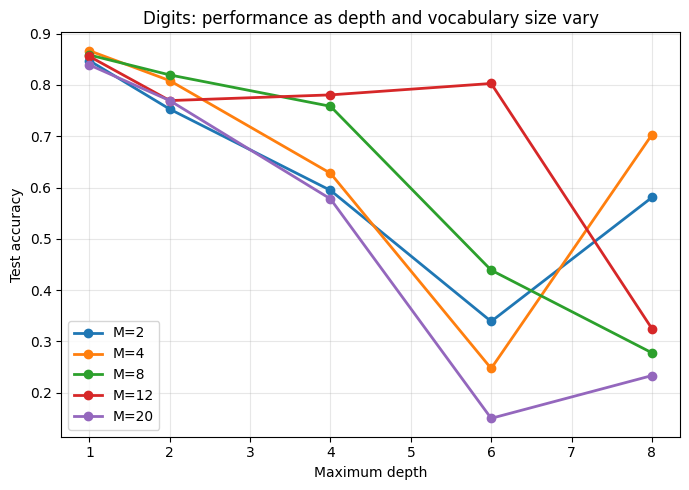

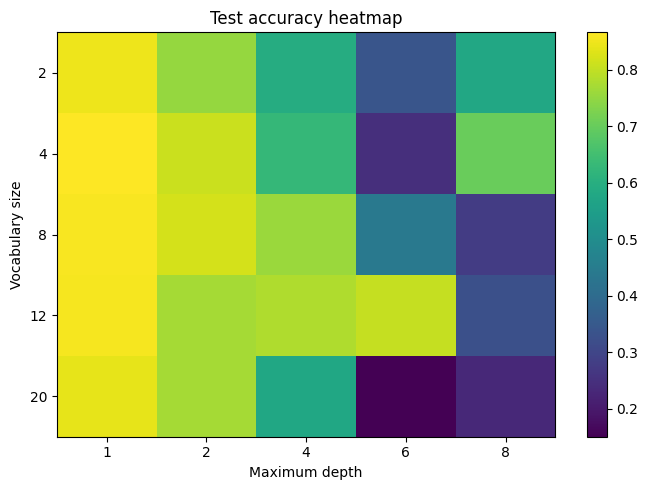

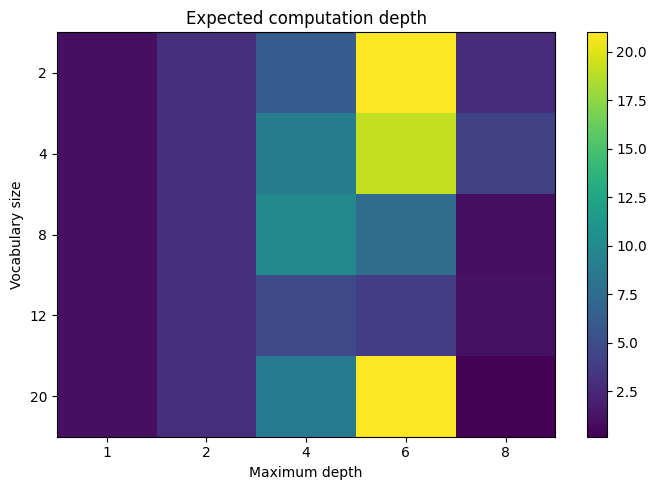

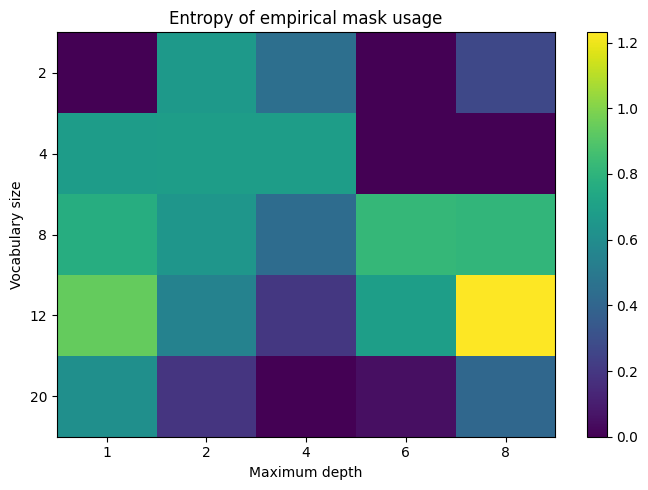

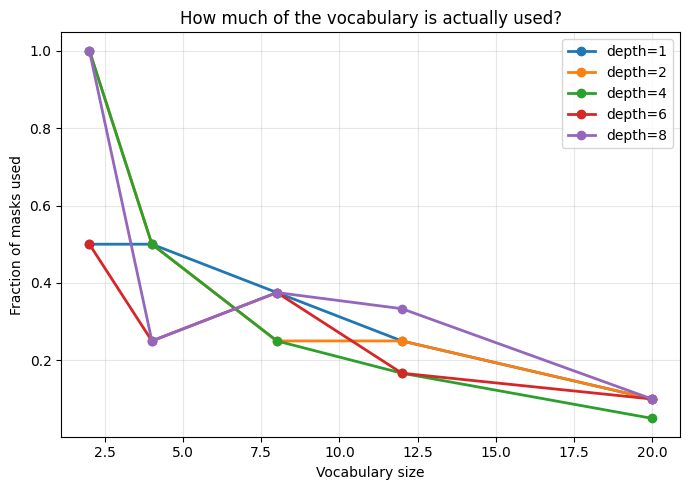

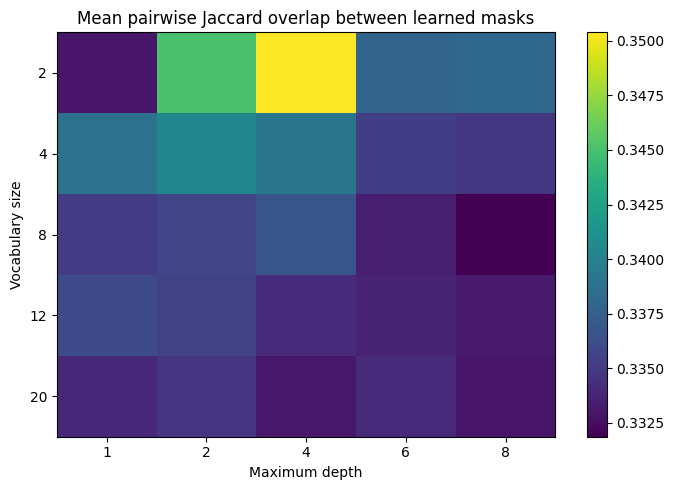


Best model: num_masks=2, max_steps=1


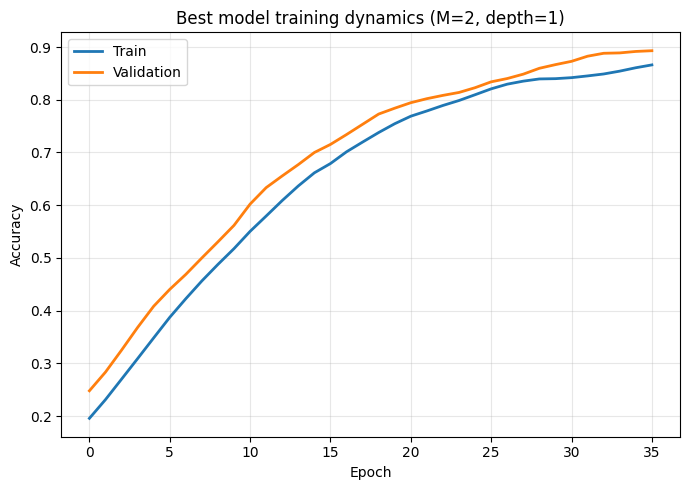

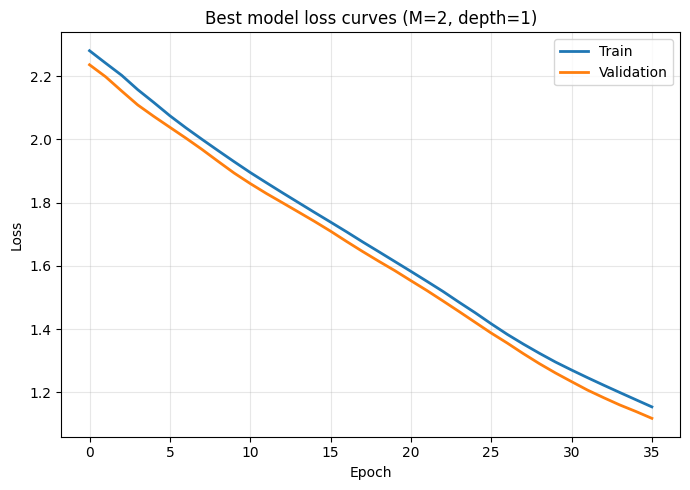

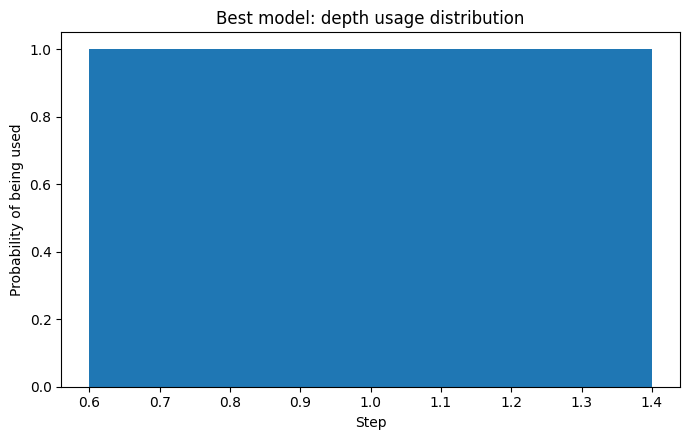

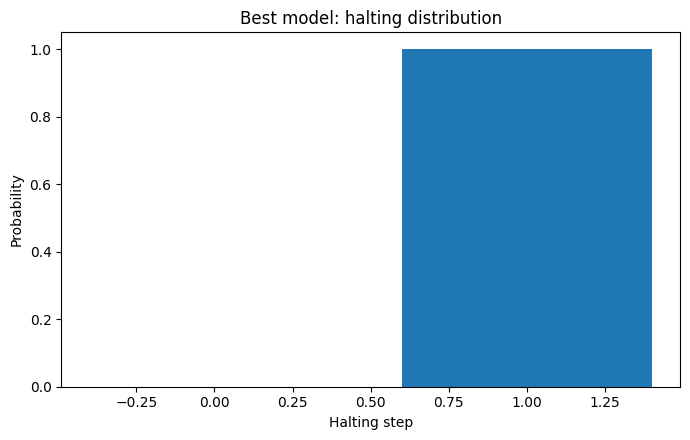

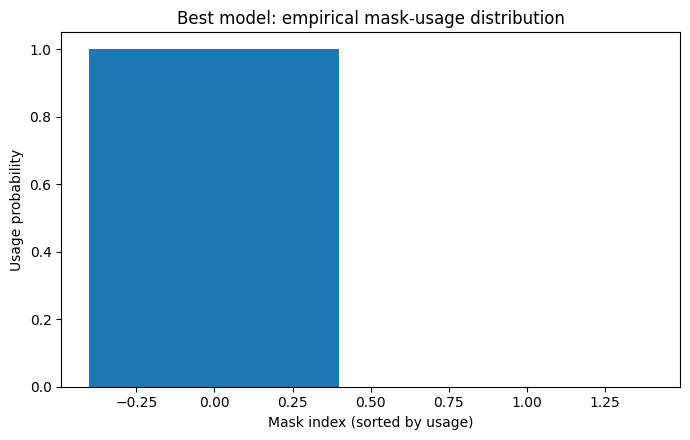

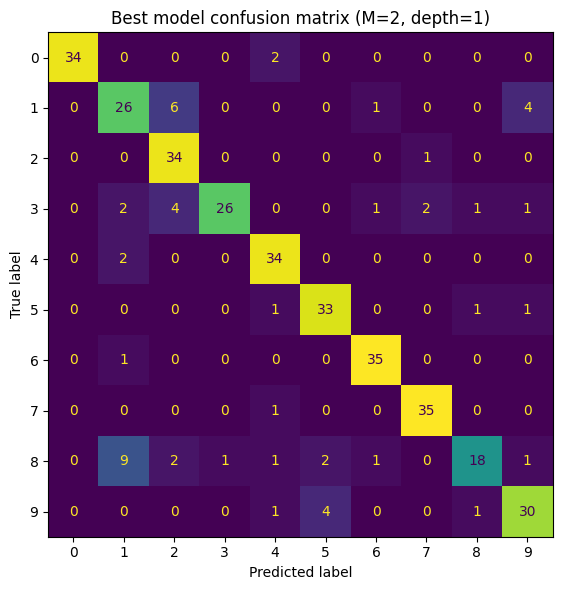

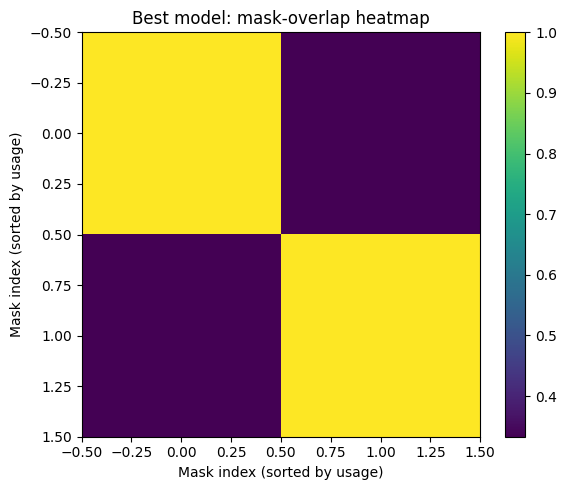

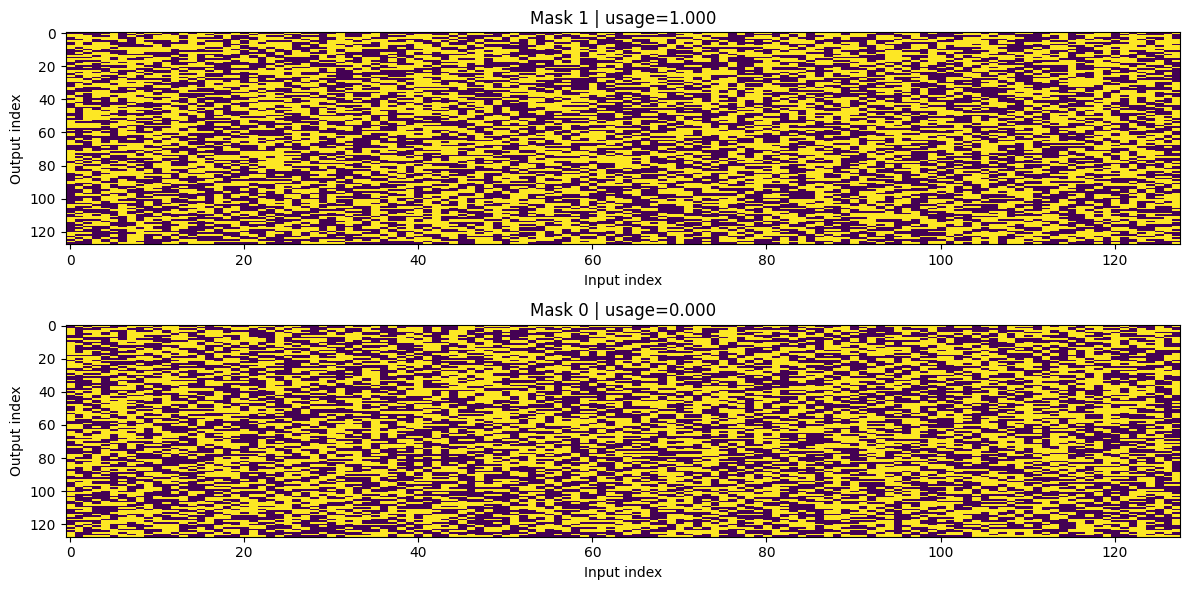


Compact sweep summary:
M= 2, depth= 1 | test acc=0.8472 | expected depth=1.000 | mask entropy=-0.000 | used masks=1/2 | mean overlap=0.333
M= 2, depth= 2 | test acc=0.7528 | expected depth=3.000 | mask entropy=0.659 | used masks=2/2 | mean overlap=0.345
M= 2, depth= 4 | test acc=0.5944 | expected depth=6.194 | mask entropy=0.449 | used masks=2/2 | mean overlap=0.350
M= 2, depth= 6 | test acc=0.3389 | expected depth=21.000 | mask entropy=-0.000 | used masks=1/2 | mean overlap=0.338
M= 2, depth= 8 | test acc=0.5806 | expected depth=2.769 | mask entropy=0.266 | used masks=2/2 | mean overlap=0.338
M= 4, depth= 1 | test acc=0.8667 | expected depth=1.000 | mask entropy=0.678 | used masks=2/4 | mean overlap=0.339
M= 4, depth= 2 | test acc=0.8083 | expected depth=3.000 | mask entropy=0.686 | used masks=2/4 | mean overlap=0.340
M= 4, depth= 4 | test acc=0.6278 | expected depth=9.028 | mask entropy=0.687 | used masks=2/4 | mean overlap=0.339
M= 4, depth= 6 | test acc=0.2472 | expected depth=19.

In [8]:
# ============================================================
# Mask Vocabulary + Routing (Digits)
# Sweep over depth and vocabulary size
# Keeps the same double-scoring mechanism
# ============================================================

import copy, random, math
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# Assumes these are already defined in an earlier cell:
#   signed_kaiming_constant_
#   GetSubnet
#   LinearSubnet
# ============================================================


# ============================================================
# Device / seed
# ============================================================
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)


# ============================================================
# Dataset
# ============================================================
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

batch_size = 128
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=batch_size, shuffle=False)


# ============================================================
# Helpers
# ============================================================
def smooth(x, k=5):
    x = np.asarray(x, dtype=float)
    if len(x) < k:
        return x
    return np.convolve(x, np.ones(k) / k, mode='valid')

def jaccard(A, B):
    A = A > 0.5
    B = B > 0.5
    union = np.logical_or(A, B).sum()
    if union == 0:
        return 1.0
    return np.logical_and(A, B).sum() / union

def empirical_entropy(probs, eps=1e-12):
    probs = np.asarray(probs, dtype=float)
    s = probs.sum()
    if s <= 0:
        return 0.0
    probs = probs / s
    return float(-(probs * np.log(probs + eps)).sum())

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# ============================================================
# Vocabulary Mask Layer
# ============================================================
class MaskVocabularyLayer(nn.Module):
    def __init__(self, features, num_masks, k=0.5):
        super().__init__()
        self.features = features
        self.num_masks = num_masks
        self.k = k

        self.weight = nn.Parameter(torch.empty(features, features))
        signed_kaiming_constant_(self.weight)
        self.weight.requires_grad_(False)

        self.bias = nn.Parameter(torch.zeros(features))
        self.bias.requires_grad_(False)

        # exact doubled score tensors
        self.scores = nn.ParameterList([
            nn.Parameter(torch.randn(features, 2 * features))
            for _ in range(num_masks)
        ])

        self.bias_scores = nn.ParameterList([
            nn.Parameter(torch.randn(2, features))
            for _ in range(num_masks)
        ])

    def all_masked_params(self):
        Ws = []
        bs = []
        for m in range(self.num_masks):
            mask = GetSubnet.apply(self.scores[m].abs(), self.k)
            Wm = self.weight * mask[:, :self.features]

            bmask = GetSubnet.apply(self.bias_scores[m].abs(), self.k)
            bm = self.bias * bmask[0, :self.features]

            Ws.append(Wm)
            bs.append(bm)

        W_all = torch.stack(Ws, dim=0)   # [M, F, F]
        b_all = torch.stack(bs, dim=0)   # [M, F]
        return W_all, b_all

    def forward(self, x, mask_onehot):
        """
        x: [B, F]
        mask_onehot: [B, M]
        """
        W_all, b_all = self.all_masked_params()
        W_batch = torch.einsum('bm,mij->bij', mask_onehot, W_all)
        b_batch = torch.einsum('bm,mj->bj', mask_onehot, b_all)
        y = torch.einsum('bij,bj->bi', W_batch, x) + b_batch
        return y

    @torch.no_grad()
    def get_mask(self, idx):
        mask = GetSubnet.apply(self.scores[idx].abs(), self.k)
        return mask[:, :self.features].detach().cpu().numpy()


# ============================================================
# Router
# ============================================================
class Router(nn.Module):
    def __init__(self, hidden_size, num_masks):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, num_masks + 1)   # +1 = HALT
        )

    def forward(self, h):
        return self.net(h)


def straight_through_gumbel_one_hot(logits, tau=1.0, eps=1e-20):
    """
    logits: [B, K]
    returns:
        y:   [B, K] straight-through one-hot
        idx: [B]
        probs: [B, K] soft probabilities before hardening
    """
    g = -torch.log(-torch.log(torch.rand_like(logits) + eps) + eps)
    probs = torch.softmax((logits + g) / tau, dim=-1)
    idx = probs.argmax(dim=-1)
    y_hard = F.one_hot(idx, num_classes=logits.shape[-1]).float()
    y = y_hard.detach() - probs.detach() + probs
    return y, idx, probs


# ============================================================
# Full model
# ============================================================
class VocabularyRoutingNet(nn.Module):
    def __init__(self, in_size=64, hidden_size=128, out_size=10, num_masks=8, max_steps=4, k=0.5):
        super().__init__()

        self.flatten = nn.Flatten()
        self.act = nn.ReLU()

        self.in_layer = LinearSubnet(in_size, hidden_size, k=k)
        self.vocab_layer = MaskVocabularyLayer(hidden_size, num_masks, k=k)
        self.router = Router(hidden_size, num_masks)
        self.out_layer = LinearSubnet(hidden_size, out_size, k=k)

        self.max_steps = max_steps
        self.num_masks = num_masks

        # batch-level diagnostics from most recent forward
        self.mask_usage = None
        self.depth_usage = None
        self.halt_usage = None
        self.route_entropy = None

    def forward(self, x, tau=1.0):
        x = self.flatten(x)
        h = self.act(self.in_layer(x))

        B = h.size(0)
        active = torch.ones(B, dtype=torch.bool, device=h.device)

        mask_counts = torch.zeros(self.num_masks, device=h.device)
        depth_counts = torch.zeros(self.max_steps, device=h.device)
        halt_counts = torch.zeros(self.max_steps + 1, device=h.device)
        entropy_accum = 0.0
        entropy_batches = 0

        for step in range(self.max_steps):
            if not torch.any(active):
                break

            active_idx = torch.where(active)[0]
            h_active = h[active_idx]

            if h_active.dim() == 1:
                h_active = h_active.unsqueeze(0)

            logits = self.router(h_active)
            if logits.dim() == 1:
                logits = logits.unsqueeze(0)

            if self.training:
                route_st, choice, probs = straight_through_gumbel_one_hot(logits, tau=tau)
            else:
                probs = torch.softmax(logits, dim=-1)
                choice = logits.argmax(dim=1)
                route_st = F.one_hot(choice, num_classes=self.num_masks + 1).float()

            entropy_accum += float((-(probs * torch.log(probs + 1e-12)).sum(dim=1)).mean().detach().cpu())
            entropy_batches += 1

            halt = (choice == self.num_masks)
            go = torch.logical_not(halt)

            depth_counts[step] += go.sum()

            h_next = h.clone()

            if torch.any(go):
                go_idx_local = torch.where(go)[0]
                go_idx_global = active_idx[go_idx_local]

                h_go = h[go_idx_global]
                mask_onehot_go = route_st[go_idx_local, :self.num_masks]

                h_new = self.vocab_layer(h_go, mask_onehot_go)
                h_new = self.act(h_new)

                h_next[go_idx_global] = h_new

                choice_go = choice[go_idx_local]
                for m in range(self.num_masks):
                    mask_counts[m] += (choice_go == m).sum()

            if torch.any(halt):
                halt_idx_local = torch.where(halt)[0]
                halt_counts[step] += len(halt_idx_local)

            h = h_next

            still_active = torch.zeros_like(active)
            if torch.any(go):
                still_active[go_idx_global] = True
            active = still_active

        # anything still active after max_steps is treated as halting at final bucket
        if torch.any(active):
            halt_counts[self.max_steps] += active.sum()

        self.mask_usage = mask_counts.detach().cpu().numpy()
        self.depth_usage = depth_counts.detach().cpu().numpy()
        self.halt_usage = halt_counts.detach().cpu().numpy()
        self.route_entropy = entropy_accum / max(entropy_batches, 1)

        return self.out_layer(h)


# ============================================================
# Evaluation / training
# ============================================================
@torch.no_grad()
def evaluate(model, loader, collect_stats=False):
    model.eval()
    total = 0
    correct = 0
    total_loss = 0.0
    loss_fn = nn.CrossEntropyLoss()

    depth_usage = None
    halt_usage = None
    mask_usage = None
    entropy_vals = []

    y_true = []
    y_pred = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = loss_fn(logits, y)

        preds = logits.argmax(dim=1)

        total += x.size(0)
        correct += (preds == y).sum().item()
        total_loss += loss.item() * x.size(0)

        if collect_stats:
            if depth_usage is None:
                depth_usage = model.depth_usage.copy()
                halt_usage = model.halt_usage.copy()
                mask_usage = model.mask_usage.copy()
            else:
                depth_usage += model.depth_usage
                halt_usage += model.halt_usage
                mask_usage += model.mask_usage
            entropy_vals.append(model.route_entropy)

            y_true.append(y.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    out = {
        "acc": correct / total,
        "loss": total_loss / total
    }

    if collect_stats:
        out["depth_usage"] = depth_usage
        out["halt_usage"] = halt_usage
        out["mask_usage"] = mask_usage
        out["route_entropy"] = float(np.mean(entropy_vals)) if len(entropy_vals) else 0.0
        out["y_true"] = np.concatenate(y_true) if len(y_true) else None
        out["y_pred"] = np.concatenate(y_pred) if len(y_pred) else None

    return out


def train(model, train_loader, val_loader, epochs=40, lr=1e-3, weight_decay=0.0):
    model.to(device)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    history = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": [],
        "tau": []
    }

    best_state = None
    best_val_acc = -1.0

    for ep in range(epochs):
        model.train()
        tau = max(0.30, 1.0 * (0.97 ** ep))
        running_loss = 0.0
        n_seen = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            opt.zero_grad()
            logits = model(x, tau=tau)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()

            running_loss += loss.item() * x.size(0)
            n_seen += x.size(0)

        train_stats = evaluate(model, train_loader, collect_stats=False)
        val_stats = evaluate(model, val_loader, collect_stats=False)

        history["train_acc"].append(train_stats["acc"])
        history["val_acc"].append(val_stats["acc"])
        history["train_loss"].append(running_loss / n_seen)
        history["val_loss"].append(val_stats["loss"])
        history["tau"].append(tau)

        if val_stats["acc"] > best_val_acc:
            best_val_acc = val_stats["acc"]
            best_state = copy.deepcopy(model.state_dict())

        if ep == 0 or (ep + 1) % 10 == 0 or ep == epochs - 1:
            print(
                f"epoch {ep+1:03d} | tau={tau:.3f} | "
                f"train acc={train_stats['acc']:.4f} | val acc={val_stats['acc']:.4f}"
            )

    model.load_state_dict(best_state)
    return model, history


# ============================================================
# Sweep
# ============================================================
depth_grid = [1, 2, 4, 6, 8]
mask_grid  = [2, 4, 8, 12, 20]
epochs = 40
hidden_size = 128
k = 0.5

results = {}
best_key = None
best_val_acc = -1.0
best_model = None
best_history = None
best_eval = None

for num_masks in mask_grid:
    for max_steps in depth_grid:
        print("\n" + "=" * 72)
        print(f"Training config: num_masks={num_masks}, max_steps={max_steps}")
        print("=" * 72)

        model = VocabularyRoutingNet(
            in_size=64,
            hidden_size=hidden_size,
            out_size=10,
            num_masks=num_masks,
            max_steps=max_steps,
            k=k
        )

        total_params, trainable_params = count_parameters(model)
        print(f"total params={total_params}, trainable params={trainable_params}")

        model, history = train(
            model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=epochs,
            lr=1e-3,
            weight_decay=0.0
        )

        val_eval = evaluate(model, val_loader, collect_stats=True)
        test_eval = evaluate(model, test_loader, collect_stats=True)

        mask_usage = test_eval["mask_usage"]
        depth_usage = test_eval["depth_usage"]
        halt_usage = test_eval["halt_usage"]

        expected_depth = 0.0
        if depth_usage.sum() > 0:
            expected_depth = float((depth_usage * np.arange(1, len(depth_usage) + 1)).sum() / max(halt_usage.sum(), 1))

        mask_probs = mask_usage / max(mask_usage.sum(), 1)
        used_mask_fraction = float((mask_usage > 0).sum() / len(mask_usage))
        mask_entropy = empirical_entropy(mask_probs)

        masks = [model.vocab_layer.get_mask(i) for i in range(model.num_masks)]
        overlap = np.zeros((model.num_masks, model.num_masks), dtype=float)
        for i in range(model.num_masks):
            for j in range(model.num_masks):
                overlap[i, j] = jaccard(masks[i], masks[j])

        offdiag = overlap[~np.eye(model.num_masks, dtype=bool)]
        mean_offdiag_overlap = float(offdiag.mean()) if len(offdiag) else 1.0

        key = (num_masks, max_steps)
        results[key] = {
            "history": history,
            "val_acc": val_eval["acc"],
            "test_acc": test_eval["acc"],
            "val_loss": val_eval["loss"],
            "test_loss": test_eval["loss"],
            "mask_usage": mask_usage,
            "depth_usage": depth_usage,
            "halt_usage": halt_usage,
            "route_entropy": test_eval["route_entropy"],
            "expected_depth": expected_depth,
            "mask_entropy": mask_entropy,
            "used_mask_fraction": used_mask_fraction,
            "mean_offdiag_overlap": mean_offdiag_overlap,
            "overlap": overlap,
            "confusion_true": test_eval["y_true"],
            "confusion_pred": test_eval["y_pred"],
            "model_state": copy.deepcopy(model.state_dict()),
            "num_masks": num_masks,
            "max_steps": max_steps
        }

        print(
            f"val acc={val_eval['acc']:.4f} | test acc={test_eval['acc']:.4f} | "
            f"expected depth={expected_depth:.3f} | "
            f"mask entropy={mask_entropy:.3f} | "
            f"used masks={int((mask_usage > 0).sum())}/{len(mask_usage)}"
        )

        if val_eval["acc"] > best_val_acc:
            best_val_acc = val_eval["acc"]
            best_key = key
            best_model = VocabularyRoutingNet(
                in_size=64,
                hidden_size=hidden_size,
                out_size=10,
                num_masks=num_masks,
                max_steps=max_steps,
                k=k
            ).to(device)
            best_model.load_state_dict(copy.deepcopy(model.state_dict()))
            best_history = copy.deepcopy(history)
            best_eval = copy.deepcopy(results[key])

print("\nBest configuration:", best_key, "with val acc =", best_val_acc)


# ============================================================
# Convert sweep results to arrays
# ============================================================
test_acc_grid = np.zeros((len(mask_grid), len(depth_grid)))
expected_depth_grid = np.zeros((len(mask_grid), len(depth_grid)))
mask_entropy_grid = np.zeros((len(mask_grid), len(depth_grid)))
used_mask_fraction_grid = np.zeros((len(mask_grid), len(depth_grid)))
overlap_grid = np.zeros((len(mask_grid), len(depth_grid)))

for i, num_masks in enumerate(mask_grid):
    for j, max_steps in enumerate(depth_grid):
        r = results[(num_masks, max_steps)]
        test_acc_grid[i, j] = r["test_acc"]
        expected_depth_grid[i, j] = r["expected_depth"]
        mask_entropy_grid[i, j] = r["mask_entropy"]
        used_mask_fraction_grid[i, j] = r["used_mask_fraction"]
        overlap_grid[i, j] = r["mean_offdiag_overlap"]


# ============================================================
# Figure 1: Accuracy vs depth for each vocabulary size
# ============================================================
plt.figure(figsize=(7, 5))
for i, num_masks in enumerate(mask_grid):
    plt.plot(depth_grid, test_acc_grid[i], marker='o', linewidth=2, label=f"M={num_masks}")
plt.xlabel("Maximum depth")
plt.ylabel("Test accuracy")
plt.title("Digits: performance as depth and vocabulary size vary")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 2: Heatmap of test accuracy
# ============================================================
plt.figure(figsize=(7, 5))
im = plt.imshow(test_acc_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(depth_grid)), depth_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum depth")
plt.ylabel("Vocabulary size")
plt.title("Test accuracy heatmap")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 3: Expected depth heatmap
# ============================================================
plt.figure(figsize=(7, 5))
im = plt.imshow(expected_depth_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(depth_grid)), depth_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum depth")
plt.ylabel("Vocabulary size")
plt.title("Expected computation depth")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 4: Mask entropy heatmap
# ============================================================
plt.figure(figsize=(7, 5))
im = plt.imshow(mask_entropy_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(depth_grid)), depth_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum depth")
plt.ylabel("Vocabulary size")
plt.title("Entropy of empirical mask usage")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 5: Fraction of masks actually used
# ============================================================
plt.figure(figsize=(7, 5))
for j, max_steps in enumerate(depth_grid):
    vals = [used_mask_fraction_grid[i, j] for i in range(len(mask_grid))]
    plt.plot(mask_grid, vals, marker='o', linewidth=2, label=f"depth={max_steps}")
plt.xlabel("Vocabulary size")
plt.ylabel("Fraction of masks used")
plt.title("How much of the vocabulary is actually used?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 6: Mean off-diagonal mask overlap
# ============================================================
plt.figure(figsize=(7, 5))
im = plt.imshow(overlap_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(depth_grid)), depth_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum depth")
plt.ylabel("Vocabulary size")
plt.title("Mean pairwise Jaccard overlap between learned masks")
plt.tight_layout()
plt.show()


# ============================================================
# Best-model graphics
# ============================================================
best_num_masks, best_max_steps = best_key
print(f"\nBest model: num_masks={best_num_masks}, max_steps={best_max_steps}")
best_masks = [best_model.vocab_layer.get_mask(i) for i in range(best_model.num_masks)]


# ============================================================
# Figure 7: Smoothed train / validation accuracy for best model
# ============================================================
plt.figure(figsize=(7, 5))
plt.plot(smooth(best_history["train_acc"], k=5), linewidth=2, label="Train")
plt.plot(smooth(best_history["val_acc"], k=5), linewidth=2, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Best model training dynamics (M={best_num_masks}, depth={best_max_steps})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 8: Smoothed train / validation loss for best model
# ============================================================
plt.figure(figsize=(7, 5))
plt.plot(smooth(best_history["train_loss"], k=5), linewidth=2, label="Train")
plt.plot(smooth(best_history["val_loss"], k=5), linewidth=2, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Best model loss curves (M={best_num_masks}, depth={best_max_steps})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 9: Normalized depth-usage distribution for best model
# ============================================================
depth_usage = best_eval["depth_usage"].astype(float)
halt_usage = best_eval["halt_usage"].astype(float)

depth_probs = depth_usage / max(depth_usage.sum(), 1.0)
halt_probs = halt_usage / max(halt_usage.sum(), 1.0)

plt.figure(figsize=(7, 4.5))
plt.bar(np.arange(1, len(depth_probs) + 1), depth_probs)
plt.xlabel("Step")
plt.ylabel("Probability of being used")
plt.title("Best model: depth usage distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.bar(np.arange(len(halt_probs)), halt_probs)
plt.xlabel("Halting step")
plt.ylabel("Probability")
plt.title("Best model: halting distribution")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 10: Sorted mask-usage distribution for best model
# ============================================================
mask_usage = best_eval["mask_usage"].astype(float)
mask_probs = mask_usage / max(mask_usage.sum(), 1.0)
order = np.argsort(-mask_probs)

plt.figure(figsize=(7, 4.5))
plt.bar(np.arange(len(mask_probs)), mask_probs[order])
plt.xlabel("Mask index (sorted by usage)")
plt.ylabel("Usage probability")
plt.title("Best model: empirical mask-usage distribution")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 11: Confusion matrix for best model
# ============================================================
cm = confusion_matrix(best_eval["confusion_true"], best_eval["confusion_pred"])
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Best model confusion matrix (M={best_num_masks}, depth={best_max_steps})")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 12: Mask-overlap heatmap for best model
# ============================================================
best_overlap = best_eval["overlap"]
usage_order = np.argsort(-mask_usage)

plt.figure(figsize=(6, 5))
im = plt.imshow(best_overlap[usage_order][:, usage_order], aspect='auto')
plt.colorbar(im)
plt.xlabel("Mask index (sorted by usage)")
plt.ylabel("Mask index (sorted by usage)")
plt.title("Best model: mask-overlap heatmap")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 13: Show a few representative masks from the best model
# ============================================================
num_show = min(6, best_model.num_masks)
top_mask_indices = usage_order[:num_show]

fig, axes = plt.subplots(2, int(np.ceil(num_show / 2)), figsize=(12, 6))
axes = np.array(axes).reshape(-1)

for ax, idx in zip(axes, top_mask_indices):
    ax.imshow(best_masks[idx], aspect='auto', interpolation='nearest')
    ax.set_title(f"Mask {idx} | usage={mask_probs[idx]:.3f}")
    ax.set_xlabel("Input index")
    ax.set_ylabel("Output index")

for ax in axes[num_show:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Print compact numeric summary
# ============================================================
print("\nCompact sweep summary:")
for num_masks in mask_grid:
    for max_steps in depth_grid:
        r = results[(num_masks, max_steps)]
        print(
            f"M={num_masks:>2}, depth={max_steps:>2} | "
            f"test acc={r['test_acc']:.4f} | "
            f"expected depth={r['expected_depth']:.3f} | "
            f"mask entropy={r['mask_entropy']:.3f} | "
            f"used masks={int((r['mask_usage']>0).sum())}/{len(r['mask_usage'])} | "
            f"mean overlap={r['mean_offdiag_overlap']:.3f}"
        )

device: cuda

Training config: num_masks=2, max_steps=2
total params=424866, trainable params=415896
epoch 001 | tau=1.000 | train acc=0.2080 | val acc=0.1979
epoch 010 | tau=0.760 | train acc=0.3064 | val acc=0.3056
epoch 020 | tau=0.561 | train acc=0.3960 | val acc=0.4028
epoch 030 | tau=0.413 | train acc=0.3516 | val acc=0.3854
epoch 040 | tau=0.305 | train acc=0.4961 | val acc=0.4861
val acc=0.5417 | test acc=0.5167 | expected seq len=2.000 | token entropy=0.457 | used tokens=2/2

Training config: num_masks=2, max_steps=4
total params=425122, trainable params=416152
epoch 001 | tau=1.000 | train acc=0.1427 | val acc=0.1285
epoch 010 | tau=0.760 | train acc=0.1366 | val acc=0.1285
epoch 020 | tau=0.561 | train acc=0.1218 | val acc=0.1076
epoch 030 | tau=0.413 | train acc=0.1784 | val acc=0.1632
epoch 040 | tau=0.305 | train acc=0.1445 | val acc=0.1493
val acc=0.1944 | test acc=0.1944 | expected seq len=4.000 | token entropy=-0.000 | used tokens=1/2

Training config: num_masks=2, max

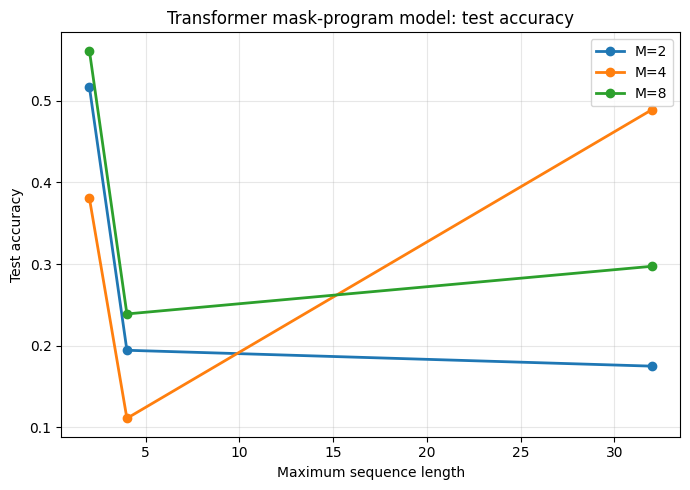

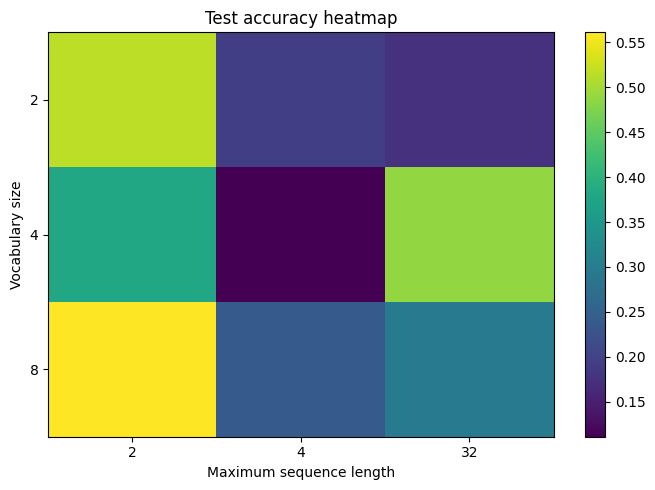

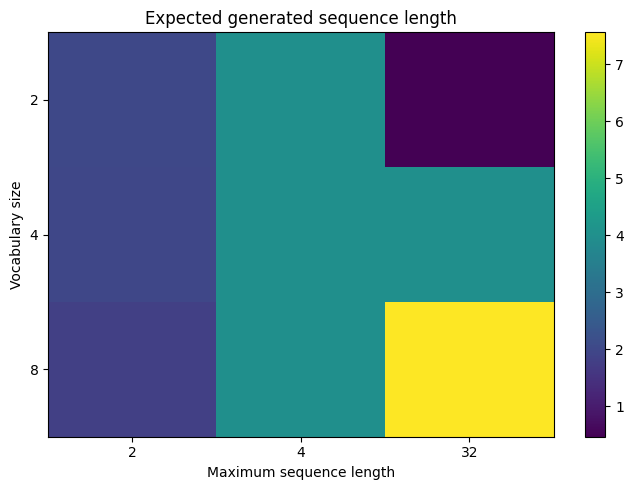

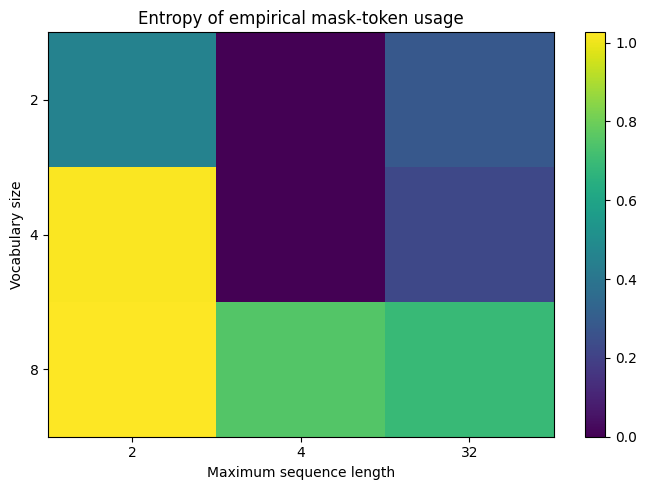

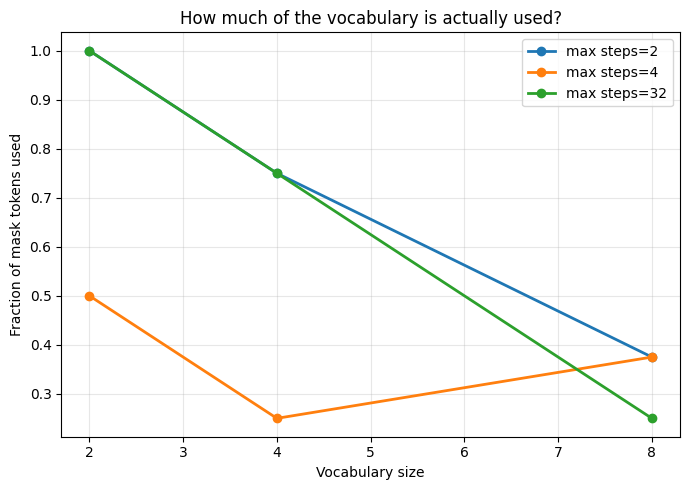

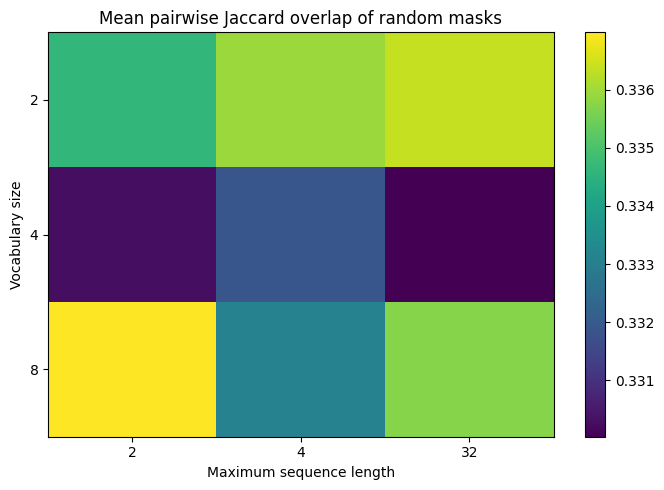


Best model: num_masks=2, max_steps=2


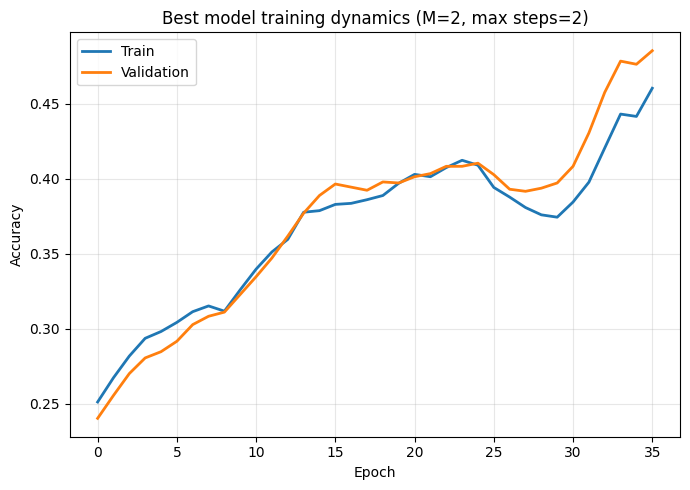

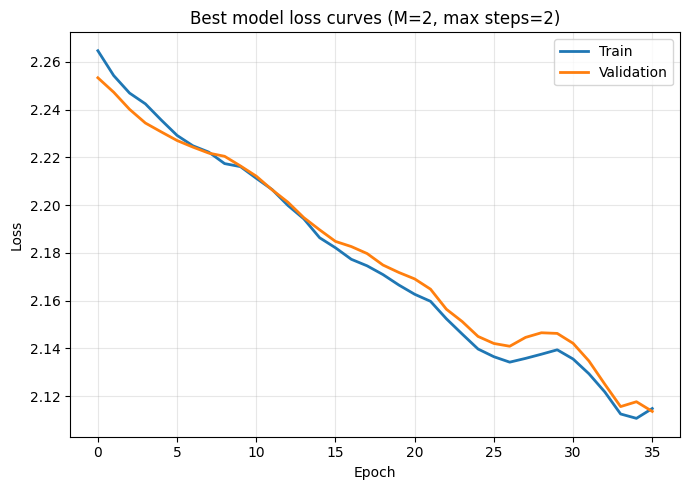

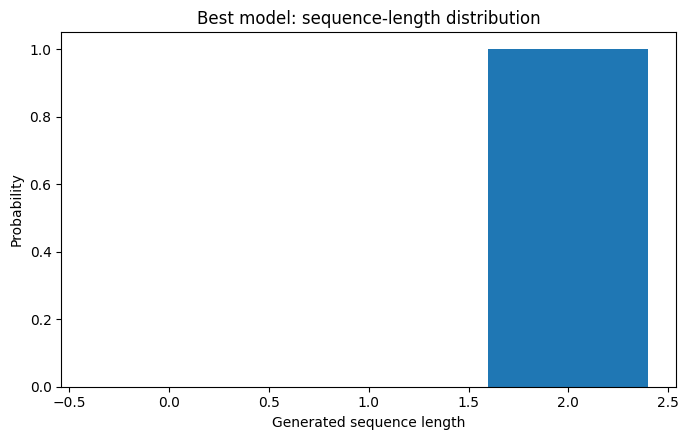

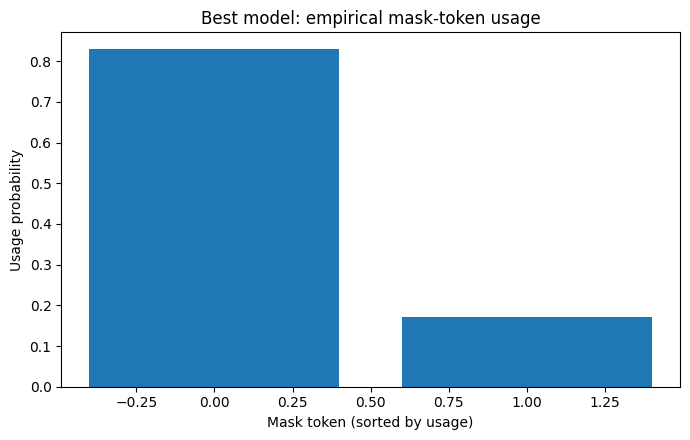

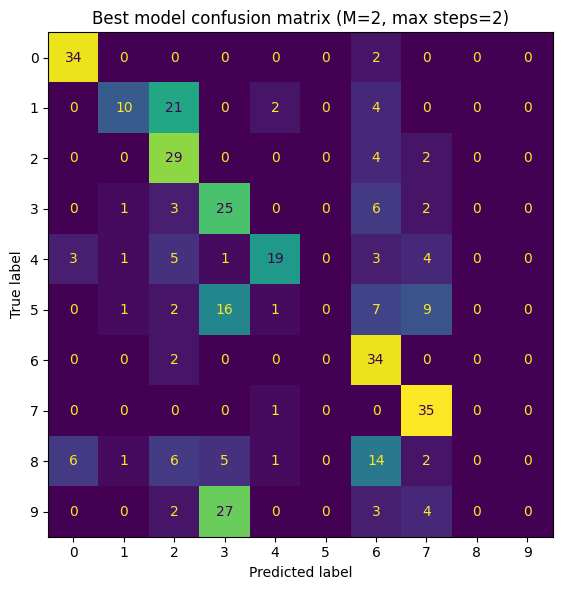

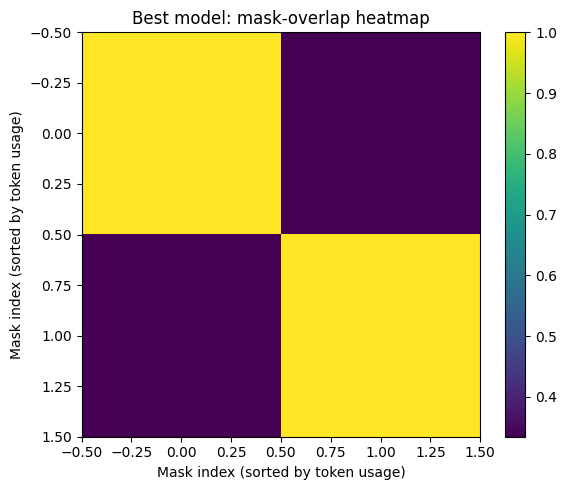

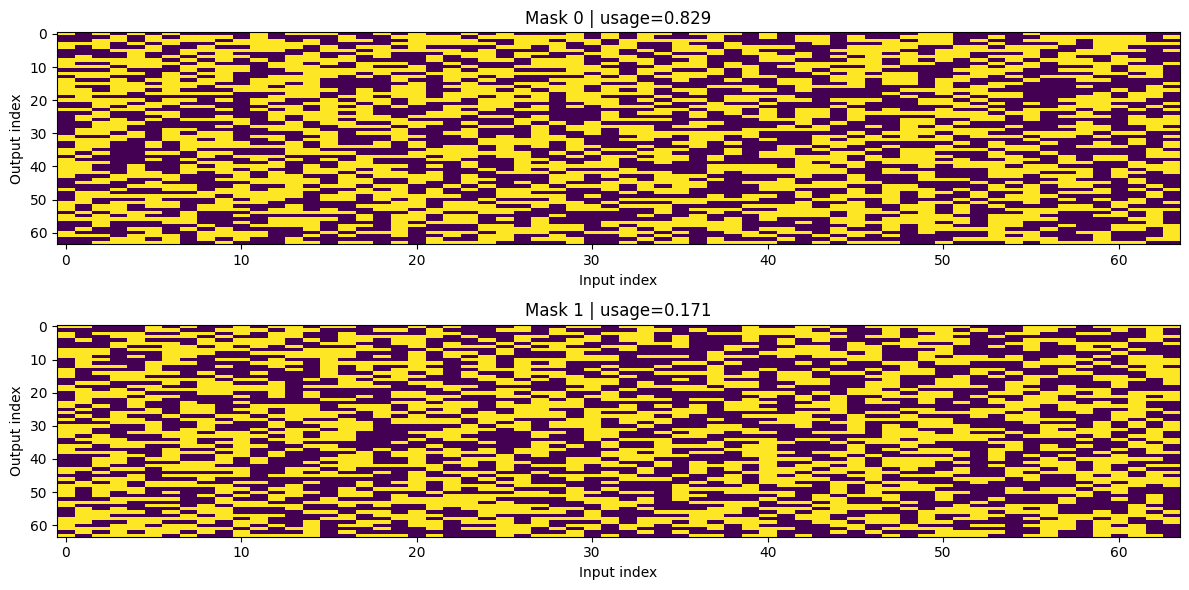


Most common generated sequences for the best model:
 232 : <START> M0 M0
  71 : <START> <START> M0
  54 : <START> M1 M1
   2 : <START> <START> M1
   1 : <START> <START> <START>

Compact sweep summary:
M= 2, max_steps= 2 | test acc=0.5167 | expected len=2.000 | token entropy=0.457 | used tokens=2/2
M= 2, max_steps= 4 | test acc=0.1944 | expected len=4.000 | token entropy=-0.000 | used tokens=1/2
M= 2, max_steps=32 | test acc=0.1750 | expected len=0.464 | token entropy=0.283 | used tokens=2/2
M= 4, max_steps= 2 | test acc=0.3806 | expected len=1.967 | token entropy=1.020 | used tokens=3/4
M= 4, max_steps= 4 | test acc=0.1111 | expected len=3.989 | token entropy=-0.000 | used tokens=1/4
M= 4, max_steps=32 | test acc=0.4889 | expected len=4.000 | token entropy=0.220 | used tokens=3/4
M= 8, max_steps= 2 | test acc=0.5611 | expected len=1.819 | token entropy=1.026 | used tokens=3/8
M= 8, max_steps= 4 | test acc=0.2389 | expected len=4.000 | token entropy=0.751 | used tokens=3/8
M= 8, max_st

In [9]:
# ============================================================
# Transformer over a fixed random vocabulary of masks (Digits)
# Assumes already defined in previous cell:
#   - signed_kaiming_constant_
#   - GetSubnet
#   - LinearSubnet
# ============================================================

import copy, random, math
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# Device / seed
# ============================================================
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)


# ============================================================
# Dataset
# ============================================================
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

batch_size = 128
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=batch_size, shuffle=False)


# ============================================================
# Helpers
# ============================================================
def smooth(x, k=5):
    x = np.asarray(x, dtype=float)
    if len(x) < k:
        return x
    return np.convolve(x, np.ones(k) / k, mode='valid')

def jaccard(A, B):
    A = A > 0.5
    B = B > 0.5
    union = np.logical_or(A, B).sum()
    if union == 0:
        return 1.0
    return np.logical_and(A, B).sum() / union

def empirical_entropy(counts, eps=1e-12):
    counts = np.asarray(counts, dtype=float)
    s = counts.sum()
    if s <= 0:
        return 0.0
    p = counts / s
    return float(-(p * np.log(p + eps)).sum())

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def token_sequence_to_string(seq, num_masks, start_id, end_id):
    pieces = []
    for t in seq:
        if t == start_id:
            pieces.append("<START>")
        elif t == end_id:
            pieces.append("<END>")
        else:
            pieces.append(f"M{t}")
    return " ".join(pieces)


# ============================================================
# Fixed random mask vocabulary
# ============================================================
class RandomMaskVocabularyLayer(nn.Module):
    """
    One shared hidden weight matrix W, but a fixed random vocabulary of masks.
    The masks are generated once at initialization via fixed random doubled
    score tensors, and are NOT trained.
    """
    def __init__(self, features, num_masks, k=0.5):
        super().__init__()
        self.features = features
        self.num_masks = num_masks
        self.k = k

        self.weight = nn.Parameter(torch.empty(features, features), requires_grad=False)
        signed_kaiming_constant_(self.weight)

        self.bias = nn.Parameter(torch.zeros(features), requires_grad=False)

        # Fixed random doubled score tensors (not trainable)
        scores = []
        bias_scores = []
        for _ in range(num_masks):
            scores.append(torch.randn(features, 2 * features))
            bias_scores.append(torch.randn(2, features))

        self.register_buffer("scores", torch.stack(scores, dim=0))          # [M, F, 2F]
        self.register_buffer("bias_scores", torch.stack(bias_scores, dim=0))# [M, 2, F]

    def all_masked_params(self):
        Ws = []
        bs = []
        for m in range(self.num_masks):
            mask = GetSubnet.apply(self.scores[m].abs(), self.k)
            Wm = self.weight * mask[:, :self.features]

            bmask = GetSubnet.apply(self.bias_scores[m].abs(), self.k)
            bm = self.bias * bmask[0, :self.features]

            Ws.append(Wm)
            bs.append(bm)

        W_all = torch.stack(Ws, dim=0)   # [M, F, F]
        b_all = torch.stack(bs, dim=0)   # [M, F]
        return W_all, b_all

    def forward(self, h, token_weights):
        """
        h: [B, F]
        token_weights: [B, M]
        """
        W_all, b_all = self.all_masked_params()
        W_batch = torch.einsum('bm,mij->bij', token_weights, W_all)   # [B, F, F]
        b_batch = torch.einsum('bm,mj->bj', token_weights, b_all)     # [B, F]
        return torch.einsum('bij,bj->bi', W_batch, h) + b_batch

    @torch.no_grad()
    def get_mask(self, idx):
        mask = GetSubnet.apply(self.scores[idx].abs(), self.k)
        return mask[:, :self.features].detach().cpu().numpy()


# ============================================================
# Transformer policy over mask tokens
# ============================================================
class MaskSequenceTransformer(nn.Module):
    """
    Decoder-style transformer over token prefixes.
    We use causal masking. The first token position is replaced by a learned
    projection of the input hidden state ('context token').
    """
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, ff_mult=4, max_len=16):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_len = max_len

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_mult * d_model,
            batch_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.out = nn.Linear(d_model, vocab_size)

    def forward(self, token_ids, context_embed):
        """
        token_ids: [B, T]
        context_embed: [B, d_model]

        Returns logits [B, T, vocab_size].
        At position 0, the input embedding is replaced by context_embed.
        """
        B, T = token_ids.shape
        pos = torch.arange(T, device=token_ids.device).unsqueeze(0).expand(B, T)

        x = self.token_emb(token_ids) + self.pos_emb(pos)
        x[:, 0, :] = context_embed

        causal_mask = torch.triu(
            torch.ones(T, T, device=token_ids.device, dtype=torch.bool),
            diagonal=1
        )

        z = self.transformer(x, mask=causal_mask)
        logits = self.out(z)
        return logits


def straight_through_gumbel_one_hot(logits, tau=1.0, eps=1e-20):
    """
    logits: [B, K]
    returns:
        y: [B, K] straight-through one-hot
        idx: [B]
        probs: [B, K]
    """
    g = -torch.log(-torch.log(torch.rand_like(logits) + eps) + eps)
    probs = torch.softmax((logits + g) / tau, dim=-1)
    idx = probs.argmax(dim=-1)
    y_hard = F.one_hot(idx, num_classes=logits.shape[-1]).float()
    y = y_hard.detach() - probs.detach() + probs
    return y, idx, probs


# ============================================================
# Full model
# ============================================================
class TransformerMaskProgramNet(nn.Module):
    """
    Input x -> hidden state h0
    Transformer autoregressively predicts a sequence of mask tokens
    over a fixed random vocabulary until <END> or max_steps.

    Token IDs:
      0,...,M-1 : mask tokens
      M         : <END>
      M+1       : <START>
    """
    def __init__(
        self,
        in_size=64,
        hidden_size=128,
        out_size=10,
        num_masks=8,
        max_steps=6,
        k=0.5,
        d_model=128,
        nhead=4,
        num_layers=2
    ):
        super().__init__()

        self.flatten = nn.Flatten()
        self.act = nn.ReLU()

        self.in_layer = LinearSubnet(in_size, hidden_size, k=k)
        self.vocab_layer = RandomMaskVocabularyLayer(hidden_size, num_masks, k=k)
        self.out_layer = LinearSubnet(hidden_size, out_size, k=k)

        self.num_masks = num_masks
        self.max_steps = max_steps

        self.end_id = num_masks
        self.start_id = num_masks + 1
        self.vocab_size = num_masks + 2  # masks + END + START

        self.context_proj = nn.Linear(hidden_size, d_model)
        self.policy = MaskSequenceTransformer(
            vocab_size=self.vocab_size,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            max_len=max_steps + 1  # start + up to max_steps predictions
        )

        # diagnostics from most recent forward
        self.token_usage = None
        self.seq_len_hist = None
        self.route_entropy = None
        self.generated_sequences = None

    def forward(self, x, tau=1.0):
        x = self.flatten(x)
        h = self.act(self.in_layer(x))                 # [B, H]
        context = self.context_proj(h)                 # [B, d_model]

        B = h.size(0)
        active = torch.ones(B, dtype=torch.bool, device=h.device)

        token_counts = torch.zeros(self.num_masks, device=h.device)
        seq_len = torch.zeros(B, dtype=torch.long, device=h.device)
        generated_tokens = [[self.start_id] for _ in range(B)]

        # current autoregressive token prefix starts as [<START>]
        prefix_tokens = torch.full((B, 1), self.start_id, dtype=torch.long, device=h.device)

        entropy_accum = 0.0
        entropy_batches = 0

        for step in range(self.max_steps):
            if not torch.any(active):
                break

            active_idx = torch.where(active)[0]
            prefix_active = prefix_tokens[active_idx]    # [Ba, Tprefix]
            context_active = context[active_idx]         # [Ba, d_model]

            logits_full = self.policy(prefix_active, context_active)  # [Ba, Tprefix, vocab]
            logits_next = logits_full[:, -1, :]                      # [Ba, vocab]

            if self.training:
                route_st, choice, probs = straight_through_gumbel_one_hot(logits_next, tau=tau)
            else:
                probs = torch.softmax(logits_next, dim=-1)
                choice = logits_next.argmax(dim=1)
                route_st = F.one_hot(choice, num_classes=self.vocab_size).float()

            entropy_accum += float((-(probs * torch.log(probs + 1e-12)).sum(dim=1)).mean().detach().cpu())
            entropy_batches += 1

            halt = (choice == self.end_id)
            go = torch.logical_not(halt)

            # append predicted token to the running prefix (hard choice)
            new_prefix = prefix_tokens.clone()
            append_col = torch.full((B, 1), self.end_id, dtype=torch.long, device=h.device)
            append_col[active_idx, 0] = choice
            new_prefix = torch.cat([new_prefix, append_col], dim=1)
            prefix_tokens = new_prefix

            # record sequences
            for loc, glob in enumerate(active_idx.tolist()):
                generated_tokens[glob].append(int(choice[loc].item()))

            # samples that continue apply a mask update
            h_next = h.clone()
            if torch.any(go):
                go_local = torch.where(go)[0]
                go_global = active_idx[go_local]

                h_go = h[go_global]
                mask_weights = route_st[go_local, :self.num_masks]  # [Bg, M]
                h_new = self.vocab_layer(h_go, mask_weights)
                h_new = self.act(h_new)
                h_next[go_global] = h_new

                choice_go = choice[go_local]
                for m in range(self.num_masks):
                    token_counts[m] += (choice_go == m).sum()

                seq_len[go_global] += 1

            h = h_next

            # update active set
            next_active = torch.zeros_like(active)
            if torch.any(go):
                next_active[go_global] = True
            active = next_active

        # Any sample still active after max_steps simply stops there.
        # prefix_tokens already contains the generated tokens; those samples
        # may not have an explicit END token.
        self.generated_sequences = generated_tokens

        seq_len_hist = np.bincount(seq_len.detach().cpu().numpy(), minlength=self.max_steps + 1)

        self.token_usage = token_counts.detach().cpu().numpy()
        self.seq_len_hist = seq_len_hist
        self.route_entropy = entropy_accum / max(entropy_batches, 1)

        return self.out_layer(h)


# ============================================================
# Evaluation / training
# ============================================================
@torch.no_grad()
def evaluate(model, loader, collect_stats=False):
    model.eval()
    total = 0
    correct = 0
    total_loss = 0.0
    loss_fn = nn.CrossEntropyLoss()

    token_usage = None
    seq_len_hist = None
    entropies = []

    y_true = []
    y_pred = []
    all_sequences = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = loss_fn(logits, y)
        preds = logits.argmax(dim=1)

        total += x.size(0)
        correct += (preds == y).sum().item()
        total_loss += loss.item() * x.size(0)

        if collect_stats:
            if token_usage is None:
                token_usage = model.token_usage.copy()
                seq_len_hist = model.seq_len_hist.copy()
            else:
                token_usage += model.token_usage
                seq_len_hist += model.seq_len_hist

            entropies.append(model.route_entropy)
            all_sequences.extend(model.generated_sequences)

            y_true.append(y.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    out = {
        "acc": correct / total,
        "loss": total_loss / total
    }

    if collect_stats:
        out["token_usage"] = token_usage
        out["seq_len_hist"] = seq_len_hist
        out["route_entropy"] = float(np.mean(entropies)) if entropies else 0.0
        out["y_true"] = np.concatenate(y_true) if len(y_true) else None
        out["y_pred"] = np.concatenate(y_pred) if len(y_pred) else None
        out["sequences"] = all_sequences

    return out


def train(model, train_loader, val_loader, epochs=40, lr=1e-3, weight_decay=0.0):
    model.to(device)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    history = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": [],
        "tau": []
    }

    best_state = None
    best_val_acc = -1.0

    for ep in range(epochs):
        model.train()
        tau = max(0.30, 1.0 * (0.97 ** ep))
        running_loss = 0.0
        n_seen = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            opt.zero_grad()
            logits = model(x, tau=tau)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()

            running_loss += loss.item() * x.size(0)
            n_seen += x.size(0)

        train_stats = evaluate(model, train_loader, collect_stats=False)
        val_stats = evaluate(model, val_loader, collect_stats=False)

        history["train_acc"].append(train_stats["acc"])
        history["val_acc"].append(val_stats["acc"])
        history["train_loss"].append(running_loss / n_seen)
        history["val_loss"].append(val_stats["loss"])
        history["tau"].append(tau)

        if val_stats["acc"] > best_val_acc:
            best_val_acc = val_stats["acc"]
            best_state = copy.deepcopy(model.state_dict())

        if ep == 0 or (ep + 1) % 10 == 0 or ep == epochs - 1:
            print(
                f"epoch {ep+1:03d} | tau={tau:.3f} | "
                f"train acc={train_stats['acc']:.4f} | val acc={val_stats['acc']:.4f}"
            )

    model.load_state_dict(best_state)
    return model, history


# ============================================================
# Sweep over vocabulary size and max sequence length
# ============================================================
mask_grid = [2,4,8]
step_grid = [2, 4, 32]
epochs = 40
hidden_size = 64
k = 0.5

results = {}
best_key = None
best_val_acc = -1.0
best_model = None
best_history = None
best_eval = None

for num_masks in mask_grid:
    for max_steps in step_grid:
        print("\n" + "=" * 72)
        print(f"Training config: num_masks={num_masks}, max_steps={max_steps}")
        print("=" * 72)

        model = TransformerMaskProgramNet(
            in_size=64,
            hidden_size=hidden_size,
            out_size=10,
            num_masks=num_masks,
            max_steps=max_steps,
            k=k,
            d_model=128,
            nhead=4,
            num_layers=2
        )

        total_params, trainable_params = count_parameters(model)
        print(f"total params={total_params}, trainable params={trainable_params}")

        model, history = train(
            model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=epochs,
            lr=1e-3,
            weight_decay=0.0
        )

        val_eval = evaluate(model, val_loader, collect_stats=True)
        test_eval = evaluate(model, test_loader, collect_stats=True)

        token_usage = test_eval["token_usage"]
        seq_len_hist = test_eval["seq_len_hist"]

        seq_lengths = np.arange(len(seq_len_hist))
        expected_seq_len = float((seq_lengths * seq_len_hist).sum() / max(seq_len_hist.sum(), 1))

        token_entropy = empirical_entropy(token_usage)
        used_token_fraction = float((token_usage > 0).sum() / len(token_usage))

        masks = [model.vocab_layer.get_mask(i) for i in range(model.num_masks)]
        overlap = np.zeros((model.num_masks, model.num_masks), dtype=float)
        for i in range(model.num_masks):
            for j in range(model.num_masks):
                overlap[i, j] = jaccard(masks[i], masks[j])

        offdiag = overlap[~np.eye(model.num_masks, dtype=bool)]
        mean_offdiag_overlap = float(offdiag.mean()) if len(offdiag) else 1.0

        seq_counter = Counter(tuple(seq) for seq in test_eval["sequences"])
        common_sequences = seq_counter.most_common(10)

        key = (num_masks, max_steps)
        results[key] = {
            "history": history,
            "val_acc": val_eval["acc"],
            "test_acc": test_eval["acc"],
            "val_loss": val_eval["loss"],
            "test_loss": test_eval["loss"],
            "token_usage": token_usage,
            "seq_len_hist": seq_len_hist,
            "route_entropy": test_eval["route_entropy"],
            "expected_seq_len": expected_seq_len,
            "token_entropy": token_entropy,
            "used_token_fraction": used_token_fraction,
            "mean_offdiag_overlap": mean_offdiag_overlap,
            "overlap": overlap,
            "confusion_true": test_eval["y_true"],
            "confusion_pred": test_eval["y_pred"],
            "common_sequences": common_sequences,
            "sequences": test_eval["sequences"],
            "num_masks": num_masks,
            "max_steps": max_steps,
            "model_state": copy.deepcopy(model.state_dict())
        }

        print(
            f"val acc={val_eval['acc']:.4f} | test acc={test_eval['acc']:.4f} | "
            f"expected seq len={expected_seq_len:.3f} | "
            f"token entropy={token_entropy:.3f} | "
            f"used tokens={int((token_usage > 0).sum())}/{len(token_usage)}"
        )

        if val_eval["acc"] > best_val_acc:
            best_val_acc = val_eval["acc"]
            best_key = key
            best_model = TransformerMaskProgramNet(
                in_size=64,
                hidden_size=hidden_size,
                out_size=10,
                num_masks=num_masks,
                max_steps=max_steps,
                k=k,
                d_model=128,
                nhead=4,
                num_layers=2
            ).to(device)
            best_model.load_state_dict(copy.deepcopy(model.state_dict()))
            best_history = copy.deepcopy(history)
            best_eval = copy.deepcopy(results[key])

print("\nBest configuration:", best_key, "with val acc =", best_val_acc)


# ============================================================
# Convert sweep results to arrays
# ============================================================
test_acc_grid = np.zeros((len(mask_grid), len(step_grid)))
expected_len_grid = np.zeros((len(mask_grid), len(step_grid)))
token_entropy_grid = np.zeros((len(mask_grid), len(step_grid)))
used_token_fraction_grid = np.zeros((len(mask_grid), len(step_grid)))
overlap_grid = np.zeros((len(mask_grid), len(step_grid)))

for i, num_masks in enumerate(mask_grid):
    for j, max_steps in enumerate(step_grid):
        r = results[(num_masks, max_steps)]
        test_acc_grid[i, j] = r["test_acc"]
        expected_len_grid[i, j] = r["expected_seq_len"]
        token_entropy_grid[i, j] = r["token_entropy"]
        used_token_fraction_grid[i, j] = r["used_token_fraction"]
        overlap_grid[i, j] = r["mean_offdiag_overlap"]


# ============================================================
# Figure 1: Test accuracy vs max sequence length
# ============================================================
plt.figure(figsize=(7, 5))
for i, num_masks in enumerate(mask_grid):
    plt.plot(step_grid, test_acc_grid[i], marker='o', linewidth=2, label=f"M={num_masks}")
plt.xlabel("Maximum sequence length")
plt.ylabel("Test accuracy")
plt.title("Transformer mask-program model: test accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 2: Heatmap of test accuracy
# ============================================================
plt.figure(figsize=(7, 5))
im = plt.imshow(test_acc_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(step_grid)), step_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum sequence length")
plt.ylabel("Vocabulary size")
plt.title("Test accuracy heatmap")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 3: Expected sequence length heatmap
# ============================================================
plt.figure(figsize=(7, 5))
im = plt.imshow(expected_len_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(step_grid)), step_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum sequence length")
plt.ylabel("Vocabulary size")
plt.title("Expected generated sequence length")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 4: Token entropy heatmap
# ============================================================
plt.figure(figsize=(7, 5))
im = plt.imshow(token_entropy_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(step_grid)), step_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum sequence length")
plt.ylabel("Vocabulary size")
plt.title("Entropy of empirical mask-token usage")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 5: Fraction of mask tokens actually used
# ============================================================
plt.figure(figsize=(7, 5))
for j, max_steps in enumerate(step_grid):
    vals = [used_token_fraction_grid[i, j] for i in range(len(mask_grid))]
    plt.plot(mask_grid, vals, marker='o', linewidth=2, label=f"max steps={max_steps}")
plt.xlabel("Vocabulary size")
plt.ylabel("Fraction of mask tokens used")
plt.title("How much of the vocabulary is actually used?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 6: Mean pairwise mask overlap
# ============================================================
plt.figure(figsize=(7, 5))
im = plt.imshow(overlap_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(step_grid)), step_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum sequence length")
plt.ylabel("Vocabulary size")
plt.title("Mean pairwise Jaccard overlap of random masks")
plt.tight_layout()
plt.show()


# ============================================================
# Best-model graphics
# ============================================================
best_num_masks, best_max_steps = best_key
print(f"\nBest model: num_masks={best_num_masks}, max_steps={best_max_steps}")

best_masks = [best_model.vocab_layer.get_mask(i) for i in range(best_model.num_masks)]
best_token_usage = best_eval["token_usage"].astype(float)
best_token_probs = best_token_usage / max(best_token_usage.sum(), 1.0)
best_order = np.argsort(-best_token_probs)


# ============================================================
# Figure 7: Smoothed train / validation accuracy
# ============================================================
plt.figure(figsize=(7, 5))
plt.plot(smooth(best_history["train_acc"], k=5), linewidth=2, label="Train")
plt.plot(smooth(best_history["val_acc"], k=5), linewidth=2, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Best model training dynamics (M={best_num_masks}, max steps={best_max_steps})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 8: Smoothed train / validation loss
# ============================================================
plt.figure(figsize=(7, 5))
plt.plot(smooth(best_history["train_loss"], k=5), linewidth=2, label="Train")
plt.plot(smooth(best_history["val_loss"], k=5), linewidth=2, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Best model loss curves (M={best_num_masks}, max steps={best_max_steps})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 9: Sequence-length distribution
# ============================================================
seq_len_hist = best_eval["seq_len_hist"].astype(float)
seq_len_probs = seq_len_hist / max(seq_len_hist.sum(), 1.0)

plt.figure(figsize=(7, 4.5))
plt.bar(np.arange(len(seq_len_probs)), seq_len_probs)
plt.xlabel("Generated sequence length")
plt.ylabel("Probability")
plt.title("Best model: sequence-length distribution")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 10: Sorted token-usage distribution
# ============================================================
plt.figure(figsize=(7, 4.5))
plt.bar(np.arange(len(best_token_probs)), best_token_probs[best_order])
plt.xlabel("Mask token (sorted by usage)")
plt.ylabel("Usage probability")
plt.title("Best model: empirical mask-token usage")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 11: Confusion matrix
# ============================================================
cm = confusion_matrix(best_eval["confusion_true"], best_eval["confusion_pred"])
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Best model confusion matrix (M={best_num_masks}, max steps={best_max_steps})")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 12: Mask-overlap heatmap for the best model
# ============================================================
best_overlap = best_eval["overlap"]

plt.figure(figsize=(6, 5))
im = plt.imshow(best_overlap[best_order][:, best_order], aspect='auto')
plt.colorbar(im)
plt.xlabel("Mask index (sorted by token usage)")
plt.ylabel("Mask index (sorted by token usage)")
plt.title("Best model: mask-overlap heatmap")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 13: Representative masks
# ============================================================
num_show = min(6, best_num_masks)
top_mask_indices = best_order[:num_show]

fig, axes = plt.subplots(2, int(np.ceil(num_show / 2)), figsize=(12, 6))
axes = np.array(axes).reshape(-1)

for ax, idx in zip(axes, top_mask_indices):
    ax.imshow(best_masks[idx], aspect='auto', interpolation='nearest')
    ax.set_title(f"Mask {idx} | usage={best_token_probs[idx]:.3f}")
    ax.set_xlabel("Input index")
    ax.set_ylabel("Output index")

for ax in axes[num_show:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Figure 14: Most common generated sequences
# ============================================================
print("\nMost common generated sequences for the best model:")
for seq, cnt in best_eval["common_sequences"][:10]:
    print(f"{cnt:>4} : {token_sequence_to_string(seq, best_num_masks, best_model.start_id, best_model.end_id)}")


# ============================================================
# Compact numeric summary
# ============================================================
print("\nCompact sweep summary:")
for num_masks in mask_grid:
    for max_steps in step_grid:
        r = results[(num_masks, max_steps)]
        print(
            f"M={num_masks:>2}, max_steps={max_steps:>2} | "
            f"test acc={r['test_acc']:.4f} | "
            f"expected len={r['expected_seq_len']:.3f} | "
            f"token entropy={r['token_entropy']:.3f} | "
            f"used tokens={int((r['token_usage'] > 0).sum())}/{len(r['token_usage'])}"
        )

device: cuda

Training config: num_masks=2, max_steps=2
total params=2612238, trainable params=2587406
epoch 001 | tau=1.000 | train acc=0.3673 | val acc=0.3611 | usage reg=-0.6100 | mask div=0.0133
epoch 010 | tau=0.760 | train acc=0.9426 | val acc=0.9375 | usage reg=-0.0002 | mask div=0.0104
epoch 020 | tau=0.561 | train acc=0.9730 | val acc=0.9514 | usage reg=-0.0006 | mask div=0.0004
epoch 030 | tau=0.413 | train acc=0.9869 | val acc=0.9583 | usage reg=-0.0004 | mask div=0.9799
epoch 040 | tau=0.305 | train acc=0.9930 | val acc=0.9618 | usage reg=-0.0084 | mask div=0.9877
val acc=0.9618 | test acc=0.9500 | expected len=2.000 | token entropy=-0.000 | used tokens=1/2

Training config: num_masks=2, max_steps=8
total params=2613006, trainable params=2588174
epoch 001 | tau=1.000 | train acc=0.1001 | val acc=0.0972 | usage reg=-0.7127 | mask div=0.1134
epoch 010 | tau=0.760 | train acc=0.8590 | val acc=0.8264 | usage reg=-0.6932 | mask div=0.0000
epoch 020 | tau=0.561 | train acc=0.9669

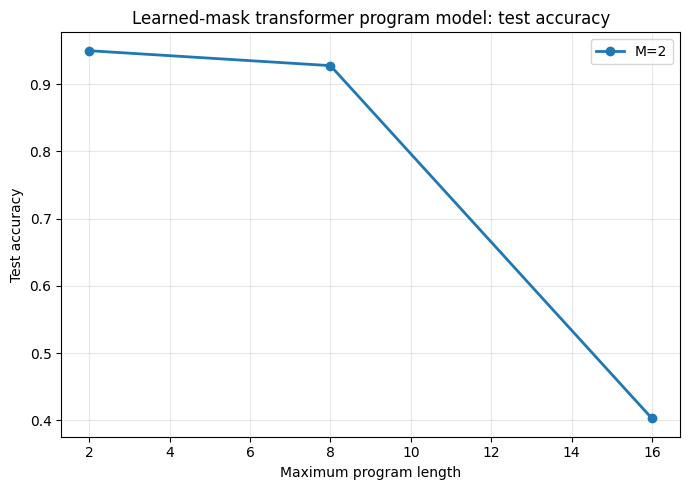

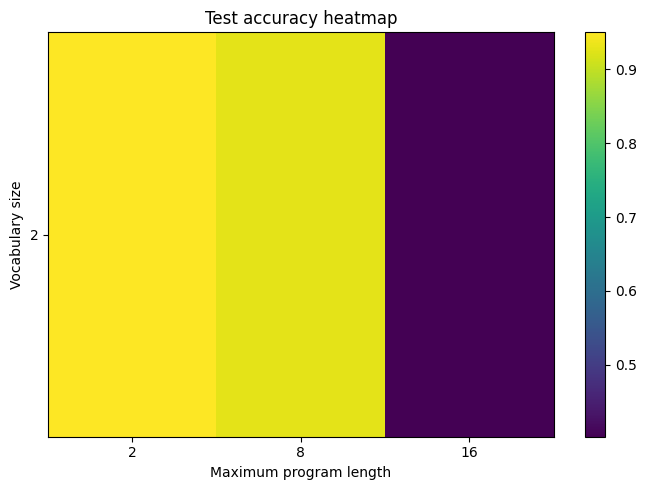

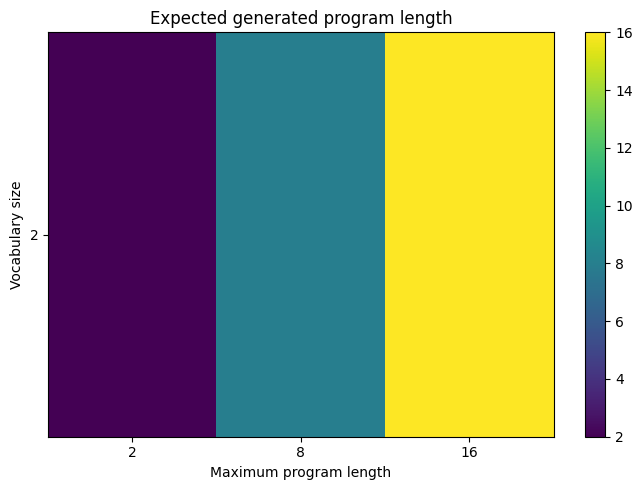

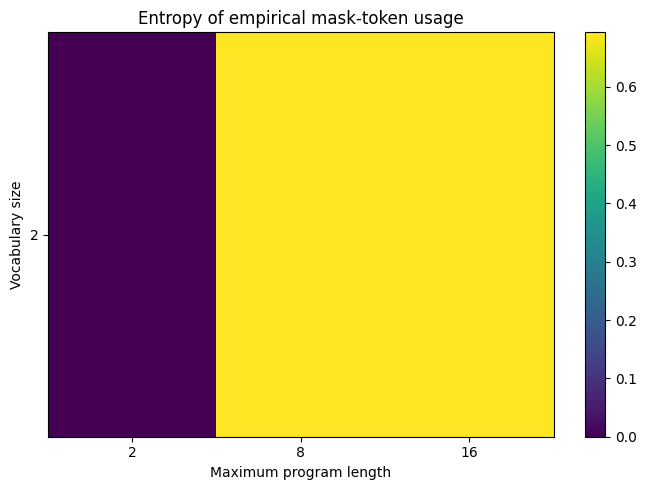

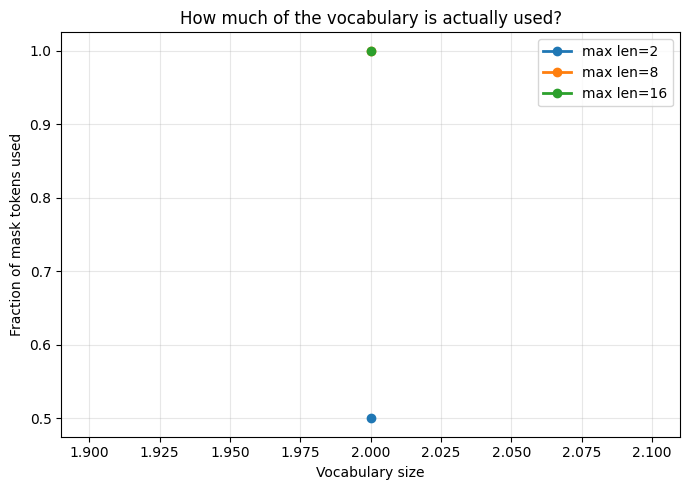

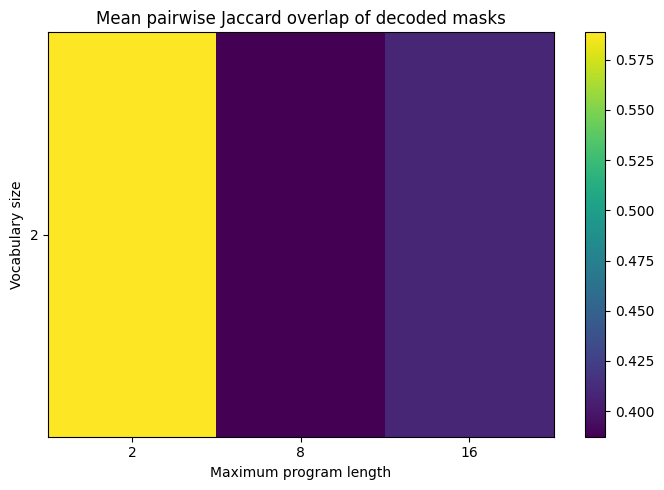


Best model: num_masks=2, max_steps=2


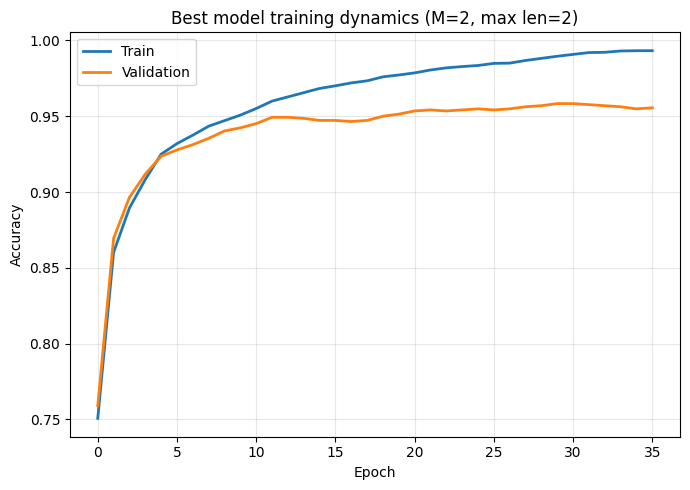

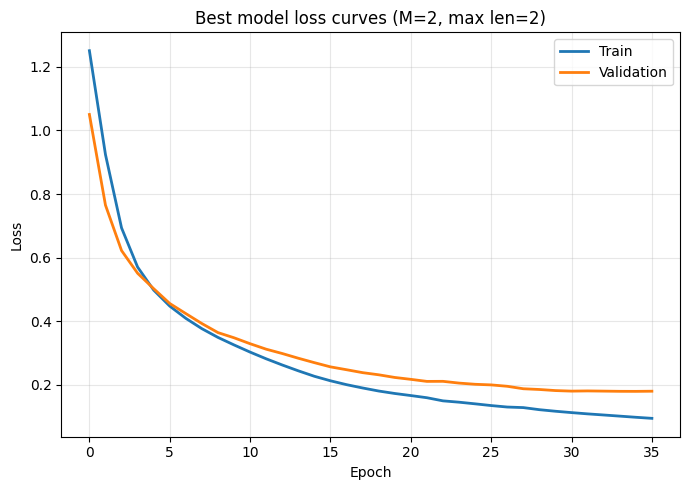

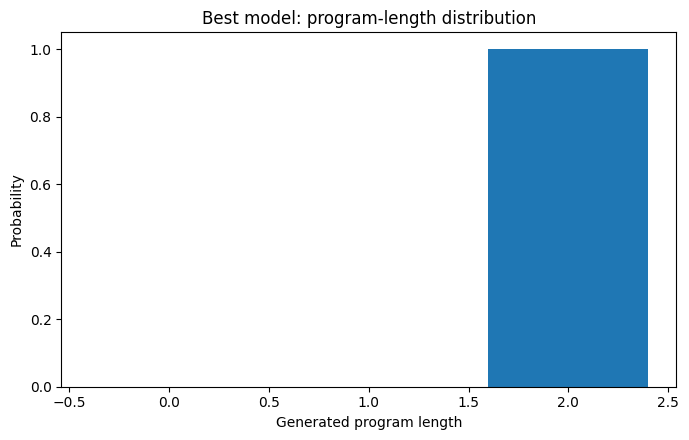

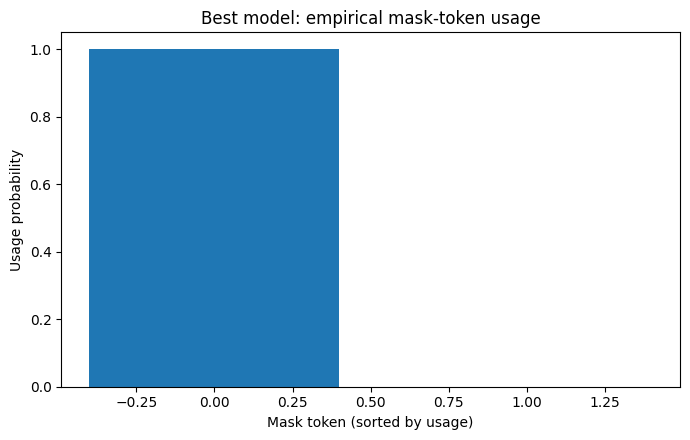

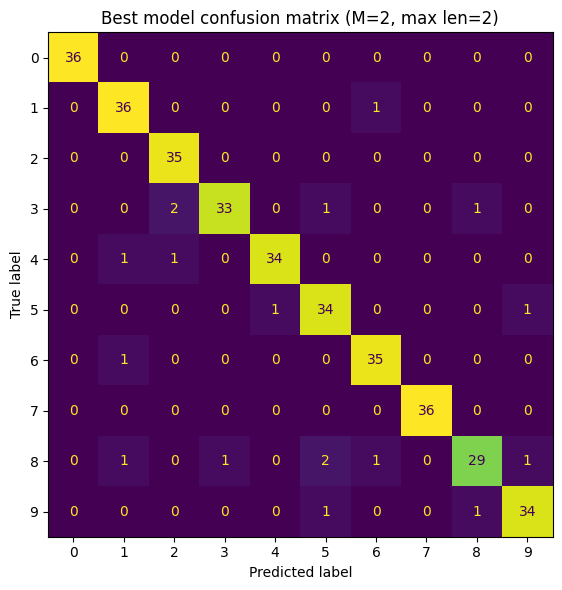

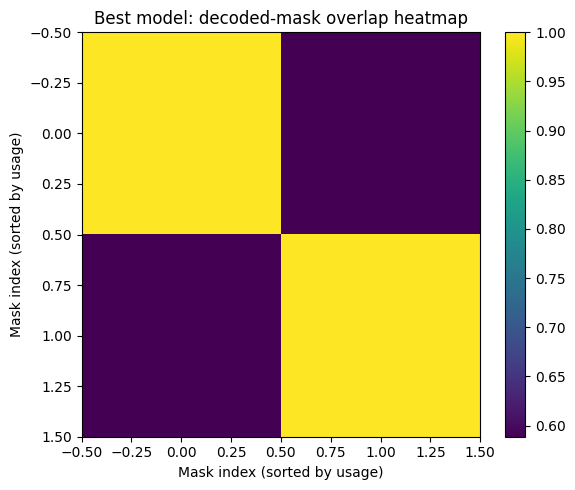

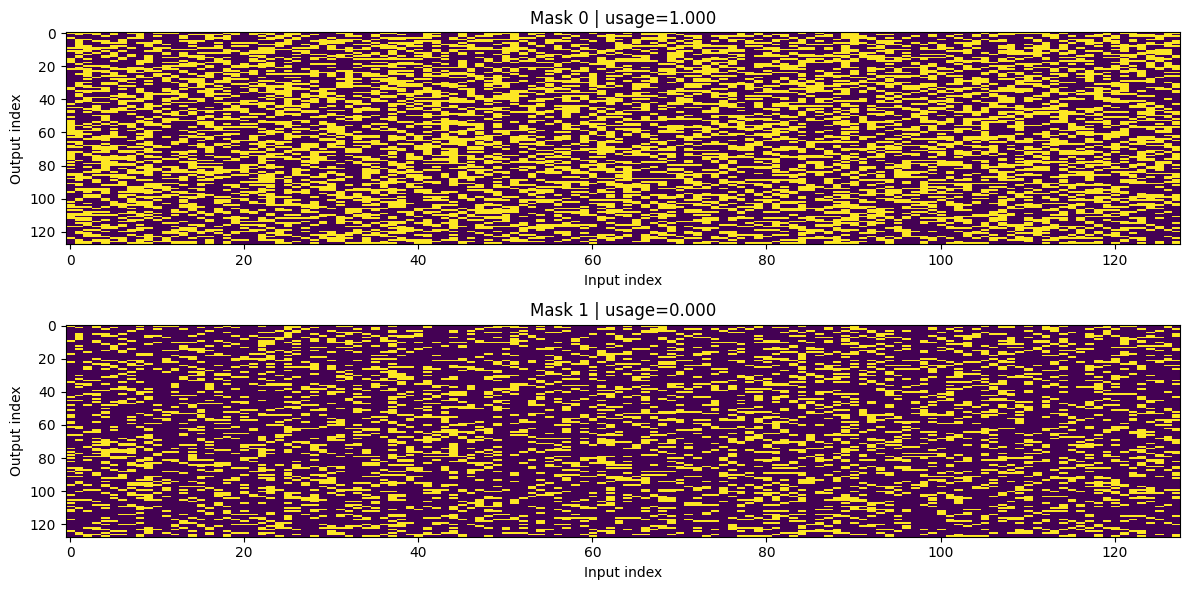

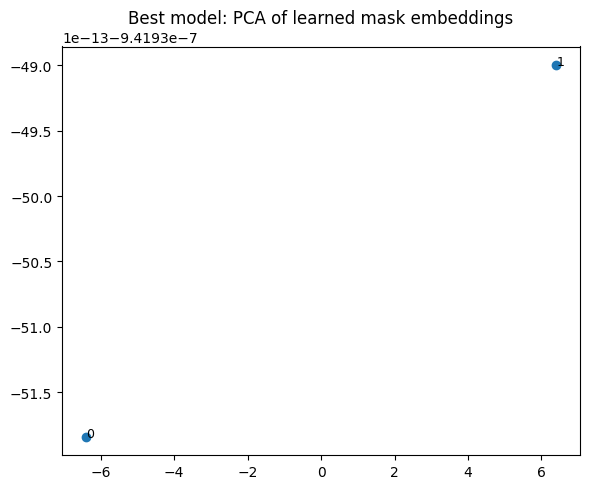

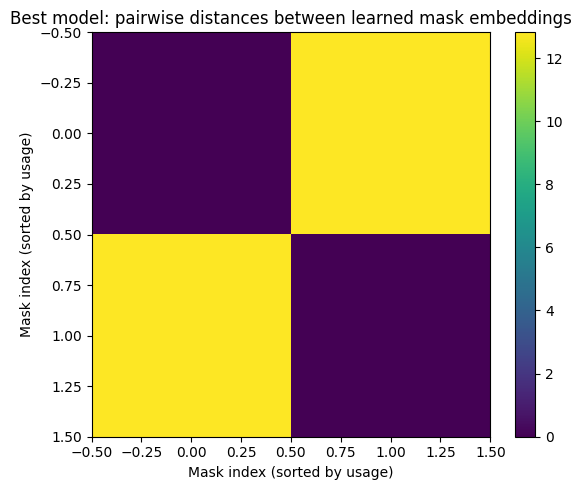


Most common generated programs for the best model:
 360 : <START> M0 M0

Compact sweep summary:
M= 2, max_steps= 2 | test acc=0.9500 | expected len=2.000 | token entropy=-0.000 | used tokens=1/2 | mean overlap=0.589
M= 2, max_steps= 8 | test acc=0.9278 | expected len=8.000 | token entropy=0.693 | used tokens=2/2 | mean overlap=0.387
M= 2, max_steps=16 | test acc=0.4028 | expected len=16.000 | token entropy=0.693 | used tokens=2/2 | mean overlap=0.409


In [10]:
# ============================================================
# Learned-mask transformer program model on digits
# with:
#   - frozen plain nn.Linear input/output layers
#   - dynamic per-step context token from CURRENT hidden state
#   - token-usage entropy regularization
#   - decoded-mask diversity regularization
#
# Assumes these are already defined in a previous cell:
#   - signed_kaiming_constant_
#   - GetSubnet
# ============================================================

import copy, random, math
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# Device / seed
# ============================================================
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)


# ============================================================
# Dataset
# ============================================================
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

batch_size = 128
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=batch_size, shuffle=False)


# ============================================================
# Helpers
# ============================================================
def smooth(x, k=5):
    x = np.asarray(x, dtype=float)
    if len(x) < k:
        return x
    return np.convolve(x, np.ones(k) / k, mode='valid')

def jaccard(A, B):
    A = A > 0.5
    B = B > 0.5
    union = np.logical_or(A, B).sum()
    if union == 0:
        return 1.0
    return np.logical_and(A, B).sum() / union

def empirical_entropy(counts, eps=1e-12):
    counts = np.asarray(counts, dtype=float)
    s = counts.sum()
    if s <= 0:
        return 0.0
    p = counts / s
    return float(-(p * np.log(p + eps)).sum())

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def token_sequence_to_string(seq, num_masks, start_id, end_id):
    pieces = []
    for t in seq:
        if t == start_id:
            pieces.append("<START>")
        elif t == end_id:
            pieces.append("<END>")
        else:
            pieces.append(f"M{t}")
    return " ".join(pieces)


# ============================================================
# Learned mask vocabulary
# ============================================================
class LearnedMaskVocabularyLayer(nn.Module):
    """
    Shared frozen hidden operator W and learned token embeddings.
    Each token embedding decodes to doubled score tensors.
    """
    def __init__(self, features, num_masks, mask_embed_dim=64, k=0.5):
        super().__init__()
        self.features = features
        self.num_masks = num_masks
        self.mask_embed_dim = mask_embed_dim
        self.k = k

        self.weight = nn.Parameter(torch.empty(features, features), requires_grad=False)
        signed_kaiming_constant_(self.weight)

        self.bias = nn.Parameter(torch.zeros(features), requires_grad=False)

        self.mask_embeddings = nn.Embedding(num_masks, mask_embed_dim)

        self.weight_score_decoder = nn.Sequential(
            nn.Linear(mask_embed_dim, mask_embed_dim),
            nn.ReLU(),
            nn.Linear(mask_embed_dim, features * (2 * features))
        )

        self.bias_score_decoder = nn.Sequential(
            nn.Linear(mask_embed_dim, mask_embed_dim),
            nn.ReLU(),
            nn.Linear(mask_embed_dim, 2 * features)
        )

    def all_decoded_scores(self):
        token_ids = torch.arange(self.num_masks, device=self.weight.device)
        emb = self.mask_embeddings(token_ids)  # [M, E]

        w_scores = self.weight_score_decoder(emb)
        w_scores = w_scores.view(self.num_masks, self.features, 2 * self.features)

        b_scores = self.bias_score_decoder(emb)
        b_scores = b_scores.view(self.num_masks, 2, self.features)

        return w_scores, b_scores

    def all_masked_params(self):
        weight_scores, bias_scores = self.all_decoded_scores()

        Ws = []
        bs = []
        for m in range(self.num_masks):
            mask = GetSubnet.apply(weight_scores[m].abs(), self.k)   # [F, 2F]
            Wm = self.weight * mask[:, :self.features]

            bmask = GetSubnet.apply(bias_scores[m].abs(), self.k)    # [2, F]
            bm = self.bias * bmask[0, :self.features]

            Ws.append(Wm)
            bs.append(bm)

        W_all = torch.stack(Ws, dim=0)   # [M, F, F]
        b_all = torch.stack(bs, dim=0)   # [M, F]
        return W_all, b_all

    def forward(self, h, token_weights):
        """
        h: [B, F]
        token_weights: [B, M]
        """
        W_all, b_all = self.all_masked_params()
        W_batch = torch.einsum('bm,mij->bij', token_weights, W_all)
        b_batch = torch.einsum('bm,mj->bj', token_weights, b_all)
        return torch.einsum('bij,bj->bi', W_batch, h) + b_batch

    def decoded_mask_diversity_loss(self):
        """
        Penalize similarity among decoded score tensors.
        Uses cosine-similarity squared on decoded WEIGHT score tensors.
        """
        weight_scores, _ = self.all_decoded_scores()     # [M, F, 2F]
        M = weight_scores.shape[0]
        flat = weight_scores.reshape(M, -1)              # [M, D]
        flat = F.normalize(flat, dim=1)

        G = flat @ flat.T                                # [M, M]
        eye = torch.eye(M, device=G.device)
        offdiag = G * (1.0 - eye)
        return (offdiag ** 2).sum() / max(M * (M - 1), 1)

    @torch.no_grad()
    def get_mask(self, idx):
        weight_scores, _ = self.all_decoded_scores()
        mask = GetSubnet.apply(weight_scores[idx].abs(), self.k)
        return mask[:, :self.features].detach().cpu().numpy()


# ============================================================
# Transformer policy
# ============================================================
class MaskSequenceTransformer(nn.Module):
    """
    Decoder-style transformer over token prefixes.
    Position 0 is the context token.
    """
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, ff_mult=4, max_len=16):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_len = max_len

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_mult * d_model,
            batch_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.out = nn.Linear(d_model, vocab_size)

    def forward(self, token_ids, context_embed):
        """
        token_ids: [B, T]
        context_embed: [B, d_model]
        """
        B, T = token_ids.shape
        pos = torch.arange(T, device=token_ids.device).unsqueeze(0).expand(B, T)

        x = self.token_emb(token_ids) + self.pos_emb(pos)

        # IMPORTANT: keep positional info at slot 0
        x[:, 0, :] = context_embed + self.pos_emb(pos)[:, 0, :]

        causal_mask = torch.triu(
            torch.ones(T, T, device=token_ids.device, dtype=torch.bool),
            diagonal=1
        )

        z = self.transformer(x, mask=causal_mask)
        logits = self.out(z)
        return logits


def straight_through_gumbel_one_hot(logits, tau=1.0, eps=1e-20):
    g = -torch.log(-torch.log(torch.rand_like(logits) + eps) + eps)
    probs = torch.softmax((logits + g) / tau, dim=-1)
    idx = probs.argmax(dim=-1)
    y_hard = F.one_hot(idx, num_classes=logits.shape[-1]).float()
    y = y_hard.detach() - probs.detach() + probs
    return y, idx, probs


# ============================================================
# Full model
# ============================================================
class TransformerLearnedMaskProgramNet(nn.Module):
    """
    Frozen plain in/out linear layers.
    Learned internal token-program model.
    Dynamic per-step context token from CURRENT hidden state.
    """
    def __init__(
        self,
        in_size=64,
        hidden_size=128,
        out_size=10,
        num_masks=8,
        max_steps=6,
        k=0.5,
        d_model=128,
        nhead=4,
        num_layers=2,
        mask_embed_dim=64
    ):
        super().__init__()

        self.flatten = nn.Flatten()
        self.act = nn.ReLU()

        # frozen plain input/output layers
        self.in_layer = LinearSubnet(in_size, hidden_size)

        self.out_layer = nn.Linear(hidden_size, out_size)

        self.vocab_layer = LearnedMaskVocabularyLayer(
            hidden_size,
            num_masks,
            mask_embed_dim=mask_embed_dim,
            k=k
        )

        self.num_masks = num_masks
        self.max_steps = max_steps

        self.end_id = num_masks
        self.start_id = num_masks + 1
        self.vocab_size = num_masks + 2

        self.context_proj = nn.Linear(hidden_size, d_model)
        self.policy = MaskSequenceTransformer(
            vocab_size=self.vocab_size,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            max_len=max_steps + 1
        )

        # diagnostics / auxiliary losses
        self.token_usage = None
        self.seq_len_hist = None
        self.route_entropy = None
        self.generated_sequences = None
        self.token_usage_entropy_loss = None
        self.mask_diversity_loss = None

    def forward(self, x, tau=1.0):
        x = self.flatten(x)
        h = self.act(self.in_layer(x))

        B = h.size(0)
        active = torch.ones(B, dtype=torch.bool, device=h.device)

        token_counts = torch.zeros(self.num_masks, device=h.device)
        seq_len = torch.zeros(B, dtype=torch.long, device=h.device)
        generated_tokens = [[self.start_id] for _ in range(B)]

        prefix_tokens = torch.full((B, 1), self.start_id, dtype=torch.long, device=h.device)

        entropy_accum = 0.0
        entropy_batches = 0
        all_mask_probs = []

        for step in range(self.max_steps):
            if not torch.any(active):
                break

            active_idx = torch.where(active)[0]
            prefix_active = prefix_tokens[active_idx]

            # DYNAMIC CONTEXT: current hidden state, not just initial state
            context_active = self.context_proj(h[active_idx])

            logits_full = self.policy(prefix_active, context_active)
            logits_next = logits_full[:, -1, :]   # [Ba, vocab]

            if self.training:
                route_st, choice, probs = straight_through_gumbel_one_hot(logits_next, tau=tau)
            else:
                probs = torch.softmax(logits_next, dim=-1)
                choice = logits_next.argmax(dim=1)
                route_st = F.one_hot(choice, num_classes=self.vocab_size).float()

            entropy_accum += float((-(probs * torch.log(probs + 1e-12)).sum(dim=1)).mean().detach().cpu())
            entropy_batches += 1

            # accumulate soft mask-token probabilities for entropy regularization
            all_mask_probs.append(probs[:, :self.num_masks])

            halt = (choice == self.end_id)
            go = torch.logical_not(halt)

            # append hard token to prefix
            append_col = torch.full((B, 1), self.end_id, dtype=torch.long, device=h.device)
            append_col[active_idx, 0] = choice
            prefix_tokens = torch.cat([prefix_tokens, append_col], dim=1)

            for loc, glob in enumerate(active_idx.tolist()):
                generated_tokens[glob].append(int(choice[loc].item()))

            h_next = h.clone()
            if torch.any(go):
                go_local = torch.where(go)[0]
                go_global = active_idx[go_local]

                h_go = h[go_global]
                mask_weights = route_st[go_local, :self.num_masks]
                h_new = self.vocab_layer(h_go, mask_weights)
                h_new = self.act(h_new)
                h_next[go_global] = h_new

                choice_go = choice[go_local]
                for m in range(self.num_masks):
                    token_counts[m] += (choice_go == m).sum()

                seq_len[go_global] += 1

            h = h_next

            next_active = torch.zeros_like(active)
            if torch.any(go):
                next_active[go_global] = True
            active = next_active

        self.generated_sequences = generated_tokens
        self.seq_len_hist = np.bincount(seq_len.detach().cpu().numpy(), minlength=self.max_steps + 1)
        self.token_usage = token_counts.detach().cpu().numpy()
        self.route_entropy = entropy_accum / max(entropy_batches, 1)

        # auxiliary losses
        if len(all_mask_probs) > 0:
            P = torch.cat(all_mask_probs, dim=0)              # [N_active_total, M]
            mean_p = P.mean(dim=0)
            # minimizing sum p log p encourages higher entropy
            self.token_usage_entropy_loss = torch.sum(mean_p * torch.log(mean_p + 1e-12))
        else:
            self.token_usage_entropy_loss = torch.tensor(0.0, device=h.device)

        self.mask_diversity_loss = self.vocab_layer.decoded_mask_diversity_loss()

        return self.out_layer(h)


# ============================================================
# Evaluation / training
# ============================================================
@torch.no_grad()
def evaluate(model, loader, collect_stats=False):
    model.eval()
    total = 0
    correct = 0
    total_loss = 0.0
    loss_fn = nn.CrossEntropyLoss()

    token_usage = None
    seq_len_hist = None
    entropies = []

    y_true = []
    y_pred = []
    all_sequences = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = loss_fn(logits, y)
        preds = logits.argmax(dim=1)

        total += x.size(0)
        correct += (preds == y).sum().item()
        total_loss += loss.item() * x.size(0)

        if collect_stats:
            if token_usage is None:
                token_usage = model.token_usage.copy()
                seq_len_hist = model.seq_len_hist.copy()
            else:
                token_usage += model.token_usage
                seq_len_hist += model.seq_len_hist

            entropies.append(model.route_entropy)
            all_sequences.extend(model.generated_sequences)

            y_true.append(y.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    out = {
        "acc": correct / total,
        "loss": total_loss / total
    }

    if collect_stats:
        out["token_usage"] = token_usage
        out["seq_len_hist"] = seq_len_hist
        out["route_entropy"] = float(np.mean(entropies)) if entropies else 0.0
        out["y_true"] = np.concatenate(y_true) if len(y_true) else None
        out["y_pred"] = np.concatenate(y_pred) if len(y_pred) else None
        out["sequences"] = all_sequences

    return out


def train(
    model,
    train_loader,
    val_loader,
    epochs=40,
    lr=1e-3,
    weight_decay=0.0,
    lambda_usage=0.05,
    lambda_mask_div=0.01
):
    model.to(device)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)
    cls_loss_fn = nn.CrossEntropyLoss()

    history = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": [],
        "tau": [],
        "usage_reg": [],
        "mask_div_reg": []
    }

    best_state = None
    best_val_acc = -1.0

    for ep in range(epochs):
        model.train()
        tau = max(0.30, 1.0 * (0.97 ** ep))
        running_loss = 0.0
        running_usage = 0.0
        running_mask_div = 0.0
        n_seen = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            opt.zero_grad()
            logits = model(x, tau=tau)

            cls_loss = cls_loss_fn(logits, y)
            usage_reg = model.token_usage_entropy_loss
            mask_div_reg = model.mask_diversity_loss

            loss = cls_loss + lambda_usage * usage_reg + lambda_mask_div * mask_div_reg
            loss.backward()
            opt.step()

            running_loss += loss.item() * x.size(0)
            running_usage += float(usage_reg.detach().cpu()) * x.size(0)
            running_mask_div += float(mask_div_reg.detach().cpu()) * x.size(0)
            n_seen += x.size(0)

        train_stats = evaluate(model, train_loader, collect_stats=False)
        val_stats = evaluate(model, val_loader, collect_stats=False)

        history["train_acc"].append(train_stats["acc"])
        history["val_acc"].append(val_stats["acc"])
        history["train_loss"].append(running_loss / n_seen)
        history["val_loss"].append(val_stats["loss"])
        history["tau"].append(tau)
        history["usage_reg"].append(running_usage / n_seen)
        history["mask_div_reg"].append(running_mask_div / n_seen)

        if val_stats["acc"] > best_val_acc:
            best_val_acc = val_stats["acc"]
            best_state = copy.deepcopy(model.state_dict())

        if ep == 0 or (ep + 1) % 10 == 0 or ep == epochs - 1:
            print(
                f"epoch {ep+1:03d} | tau={tau:.3f} | "
                f"train acc={train_stats['acc']:.4f} | val acc={val_stats['acc']:.4f} | "
                f"usage reg={running_usage/n_seen:.4f} | mask div={running_mask_div/n_seen:.4f}"
            )

    model.load_state_dict(best_state)
    return model, history


# ============================================================
# Sweep over vocabulary size and max program length
# ============================================================
mask_grid = [2]
step_grid = [2, 8, 16]

epochs = 40
hidden_size = 128
k = 0.5
mask_embed_dim = 64

results = {}
best_key = None
best_val_acc = -1.0
best_model = None
best_history = None
best_eval = None

for num_masks in mask_grid:
    for max_steps in step_grid:
        print("\n" + "=" * 72)
        print(f"Training config: num_masks={num_masks}, max_steps={max_steps}")
        print("=" * 72)

        model = TransformerLearnedMaskProgramNet(
            in_size=64,
            hidden_size=hidden_size,
            out_size=10,
            num_masks=num_masks,
            max_steps=max_steps,
            k=k,
            d_model=128,
            nhead=4,
            num_layers=2,
            mask_embed_dim=mask_embed_dim
        )

        total_params, trainable_params = count_parameters(model)
        print(f"total params={total_params}, trainable params={trainable_params}")

        model, history = train(
            model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=epochs,
            lr=1e-3,
            weight_decay=0.0,
            lambda_usage=0.05,
            lambda_mask_div=0.01
        )

        val_eval = evaluate(model, val_loader, collect_stats=True)
        test_eval = evaluate(model, test_loader, collect_stats=True)

        token_usage = test_eval["token_usage"]
        seq_len_hist = test_eval["seq_len_hist"]

        seq_lengths = np.arange(len(seq_len_hist))
        expected_seq_len = float((seq_lengths * seq_len_hist).sum() / max(seq_len_hist.sum(), 1))

        token_entropy = empirical_entropy(token_usage)
        used_token_fraction = float((token_usage > 0).sum() / len(token_usage))

        masks = [model.vocab_layer.get_mask(i) for i in range(model.num_masks)]
        overlap = np.zeros((model.num_masks, model.num_masks), dtype=float)
        for i in range(model.num_masks):
            for j in range(model.num_masks):
                overlap[i, j] = jaccard(masks[i], masks[j])

        offdiag = overlap[~np.eye(model.num_masks, dtype=bool)]
        mean_offdiag_overlap = float(offdiag.mean()) if len(offdiag) else 1.0

        seq_counter = Counter(tuple(seq) for seq in test_eval["sequences"])
        common_sequences = seq_counter.most_common(10)

        key = (num_masks, max_steps)
        results[key] = {
            "history": history,
            "val_acc": val_eval["acc"],
            "test_acc": test_eval["acc"],
            "val_loss": val_eval["loss"],
            "test_loss": test_eval["loss"],
            "token_usage": token_usage,
            "seq_len_hist": seq_len_hist,
            "route_entropy": test_eval["route_entropy"],
            "expected_seq_len": expected_seq_len,
            "token_entropy": token_entropy,
            "used_token_fraction": used_token_fraction,
            "mean_offdiag_overlap": mean_offdiag_overlap,
            "overlap": overlap,
            "confusion_true": test_eval["y_true"],
            "confusion_pred": test_eval["y_pred"],
            "common_sequences": common_sequences,
            "sequences": test_eval["sequences"],
            "num_masks": num_masks,
            "max_steps": max_steps,
            "model_state": copy.deepcopy(model.state_dict())
        }

        print(
            f"val acc={val_eval['acc']:.4f} | test acc={test_eval['acc']:.4f} | "
            f"expected len={expected_seq_len:.3f} | "
            f"token entropy={token_entropy:.3f} | "
            f"used tokens={int((token_usage > 0).sum())}/{len(token_usage)}"
        )

        if val_eval["acc"] > best_val_acc:
            best_val_acc = val_eval["acc"]
            best_key = key
            best_model = TransformerLearnedMaskProgramNet(
                in_size=64,
                hidden_size=hidden_size,
                out_size=10,
                num_masks=num_masks,
                max_steps=max_steps,
                k=k,
                d_model=128,
                nhead=4,
                num_layers=2,
                mask_embed_dim=mask_embed_dim
            ).to(device)
            best_model.load_state_dict(copy.deepcopy(model.state_dict()))
            best_history = copy.deepcopy(history)
            best_eval = copy.deepcopy(results[key])

print("\nBest configuration:", best_key, "with val acc =", best_val_acc)


# ============================================================
# Convert sweep results to arrays
# ============================================================
test_acc_grid = np.zeros((len(mask_grid), len(step_grid)))
expected_len_grid = np.zeros((len(mask_grid), len(step_grid)))
token_entropy_grid = np.zeros((len(mask_grid), len(step_grid)))
used_token_fraction_grid = np.zeros((len(mask_grid), len(step_grid)))
overlap_grid = np.zeros((len(mask_grid), len(step_grid)))

for i, num_masks in enumerate(mask_grid):
    for j, max_steps in enumerate(step_grid):
        r = results[(num_masks, max_steps)]
        test_acc_grid[i, j] = r["test_acc"]
        expected_len_grid[i, j] = r["expected_seq_len"]
        token_entropy_grid[i, j] = r["token_entropy"]
        used_token_fraction_grid[i, j] = r["used_token_fraction"]
        overlap_grid[i, j] = r["mean_offdiag_overlap"]


# ============================================================
# Figure 1: Test accuracy vs max program length
# ============================================================
plt.figure(figsize=(7, 5))
for i, num_masks in enumerate(mask_grid):
    plt.plot(step_grid, test_acc_grid[i], marker='o', linewidth=2, label=f"M={num_masks}")
plt.xlabel("Maximum program length")
plt.ylabel("Test accuracy")
plt.title("Learned-mask transformer program model: test accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 2: Accuracy heatmap
# ============================================================
plt.figure(figsize=(7, 5))
im = plt.imshow(test_acc_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(step_grid)), step_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum program length")
plt.ylabel("Vocabulary size")
plt.title("Test accuracy heatmap")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 3: Expected program length heatmap
# ============================================================
plt.figure(figsize=(7, 5))
im = plt.imshow(expected_len_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(step_grid)), step_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum program length")
plt.ylabel("Vocabulary size")
plt.title("Expected generated program length")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 4: Token entropy heatmap
# ============================================================
plt.figure(figsize=(7, 5))
im = plt.imshow(token_entropy_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(step_grid)), step_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum program length")
plt.ylabel("Vocabulary size")
plt.title("Entropy of empirical mask-token usage")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 5: Fraction of mask tokens used
# ============================================================
plt.figure(figsize=(7, 5))
for j, max_steps in enumerate(step_grid):
    vals = [used_token_fraction_grid[i, j] for i in range(len(mask_grid))]
    plt.plot(mask_grid, vals, marker='o', linewidth=2, label=f"max len={max_steps}")
plt.xlabel("Vocabulary size")
plt.ylabel("Fraction of mask tokens used")
plt.title("How much of the vocabulary is actually used?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 6: Mean pairwise overlap of decoded masks
# ============================================================
plt.figure(figsize=(7, 5))
im = plt.imshow(overlap_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(step_grid)), step_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum program length")
plt.ylabel("Vocabulary size")
plt.title("Mean pairwise Jaccard overlap of decoded masks")
plt.tight_layout()
plt.show()


# ============================================================
# Best-model graphics
# ============================================================
best_num_masks, best_max_steps = best_key
print(f"\nBest model: num_masks={best_num_masks}, max_steps={best_max_steps}")

best_masks = [best_model.vocab_layer.get_mask(i) for i in range(best_model.num_masks)]
best_token_usage = best_eval["token_usage"].astype(float)
best_token_probs = best_token_usage / max(best_token_usage.sum(), 1.0)
best_order = np.argsort(-best_token_probs)


# ============================================================
# Figure 7: Smoothed train / validation accuracy
# ============================================================
plt.figure(figsize=(7, 5))
plt.plot(smooth(best_history["train_acc"], k=5), linewidth=2, label="Train")
plt.plot(smooth(best_history["val_acc"], k=5), linewidth=2, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Best model training dynamics (M={best_num_masks}, max len={best_max_steps})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 8: Smoothed train / validation loss
# ============================================================
plt.figure(figsize=(7, 5))
plt.plot(smooth(best_history["train_loss"], k=5), linewidth=2, label="Train")
plt.plot(smooth(best_history["val_loss"], k=5), linewidth=2, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Best model loss curves (M={best_num_masks}, max len={best_max_steps})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 9: Program-length distribution
# ============================================================
seq_len_hist = best_eval["seq_len_hist"].astype(float)
seq_len_probs = seq_len_hist / max(seq_len_hist.sum(), 1.0)

plt.figure(figsize=(7, 4.5))
plt.bar(np.arange(len(seq_len_probs)), seq_len_probs)
plt.xlabel("Generated program length")
plt.ylabel("Probability")
plt.title("Best model: program-length distribution")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 10: Sorted token-usage distribution
# ============================================================
plt.figure(figsize=(7, 4.5))
plt.bar(np.arange(len(best_token_probs)), best_token_probs[best_order])
plt.xlabel("Mask token (sorted by usage)")
plt.ylabel("Usage probability")
plt.title("Best model: empirical mask-token usage")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 11: Confusion matrix
# ============================================================
cm = confusion_matrix(best_eval["confusion_true"], best_eval["confusion_pred"])
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Best model confusion matrix (M={best_num_masks}, max len={best_max_steps})")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 12: Decoded-mask overlap heatmap
# ============================================================
best_overlap = best_eval["overlap"]

plt.figure(figsize=(6, 5))
im = plt.imshow(best_overlap[best_order][:, best_order], aspect='auto')
plt.colorbar(im)
plt.xlabel("Mask index (sorted by usage)")
plt.ylabel("Mask index (sorted by usage)")
plt.title("Best model: decoded-mask overlap heatmap")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 13: Representative decoded masks
# ============================================================
num_show = min(6, best_num_masks)
top_mask_indices = best_order[:num_show]

fig, axes = plt.subplots(2, int(np.ceil(num_show / 2)), figsize=(12, 6))
axes = np.array(axes).reshape(-1)

for ax, idx in zip(axes, top_mask_indices):
    ax.imshow(best_masks[idx], aspect='auto', interpolation='nearest')
    ax.set_title(f"Mask {idx} | usage={best_token_probs[idx]:.3f}")
    ax.set_xlabel("Input index")
    ax.set_ylabel("Output index")

for ax in axes[num_show:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Figure 14: PCA of learned mask embeddings
# ============================================================
with torch.no_grad():
    E = best_model.vocab_layer.mask_embeddings.weight.detach().cpu().numpy()

Z = PCA(n_components=2).fit_transform(E)

plt.figure(figsize=(6, 5))
plt.scatter(Z[:, 0], Z[:, 1])
for i in range(len(Z)):
    plt.text(Z[i, 0], Z[i, 1], str(i), fontsize=9)
plt.title("Best model: PCA of learned mask embeddings")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 15: Pairwise distances between learned mask embeddings
# ============================================================
with torch.no_grad():
    E = best_model.vocab_layer.mask_embeddings.weight.detach().cpu().numpy()

D = np.sqrt(((E[:, None, :] - E[None, :, :]) ** 2).sum(axis=-1))

plt.figure(figsize=(6, 5))
im = plt.imshow(D[best_order][:, best_order], aspect='auto')
plt.colorbar(im)
plt.xlabel("Mask index (sorted by usage)")
plt.ylabel("Mask index (sorted by usage)")
plt.title("Best model: pairwise distances between learned mask embeddings")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 16: Most common generated programs
# ============================================================
print("\nMost common generated programs for the best model:")
for seq, cnt in best_eval["common_sequences"][:10]:
    print(f"{cnt:>4} : {token_sequence_to_string(seq, best_num_masks, best_model.start_id, best_model.end_id)}")


# ============================================================
# Compact numeric summary
# ============================================================
print("\nCompact sweep summary:")
for num_masks in mask_grid:
    for max_steps in step_grid:
        r = results[(num_masks, max_steps)]
        print(
            f"M={num_masks:>2}, max_steps={max_steps:>2} | "
            f"test acc={r['test_acc']:.4f} | "
            f"expected len={r['expected_seq_len']:.3f} | "
            f"token entropy={r['token_entropy']:.3f} | "
            f"used tokens={int((r['token_usage'] > 0).sum())}/{len(r['token_usage'])} | "
            f"mean overlap={r['mean_offdiag_overlap']:.3f}"
        )

device: cuda
[AE1] epoch 001 | train recon=0.91765 | val recon=1.35188
[AE1] epoch 020 | train recon=0.10571 | val recon=0.36326
[AE1] epoch 040 | train recon=0.04072 | val recon=0.11263
[AE1] epoch 060 | train recon=0.02442 | val recon=0.06418
[AE1] epoch 080 | train recon=0.01613 | val recon=0.05194
[READOUT] epoch 001 | train acc=0.1506 | val acc=0.2431 | train mse=0.67744 | val mse=0.86541
[READOUT] epoch 020 | train acc=0.9373 | val acc=0.9306 | train mse=0.20087 | val mse=0.35795
[READOUT] epoch 040 | train acc=0.9652 | val acc=0.9549 | train mse=0.15960 | val mse=0.27311
[READOUT] epoch 060 | train acc=0.9756 | val acc=0.9549 | train mse=0.13984 | val mse=0.22525
[READOUT] epoch 080 | train acc=0.9817 | val acc=0.9549 | train mse=0.12870 | val mse=0.19946

Frozen interface quality:
{'acc': 0.9527777777777777, 'ce': 0.3259103602833218, 'mse': 0.8219240347544352}

Training config: num_masks=4, max_steps=2
total params=2596240, trainable params=2570118
[PROGRAM] epoch 001 | tau=1.0

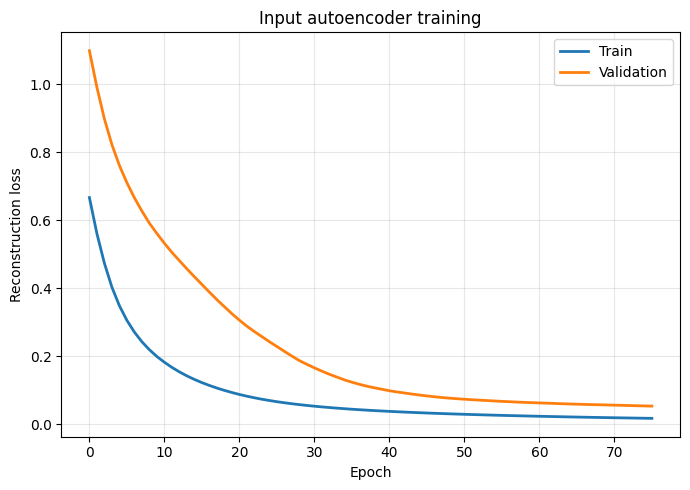

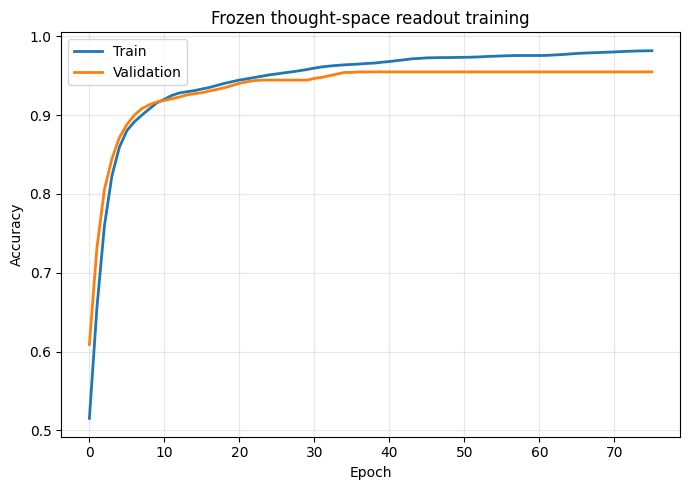

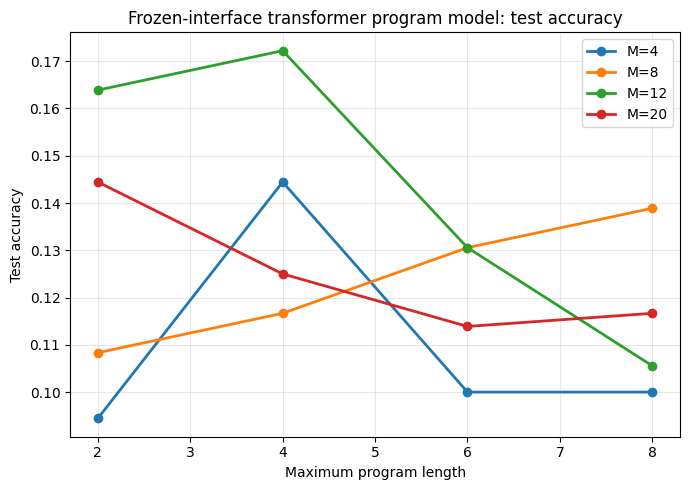

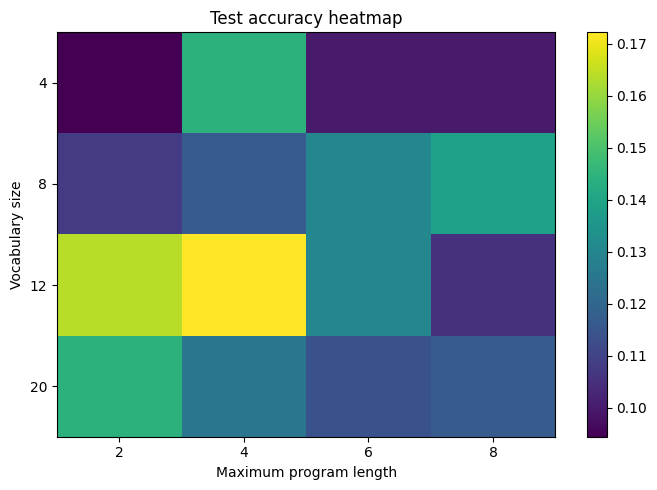

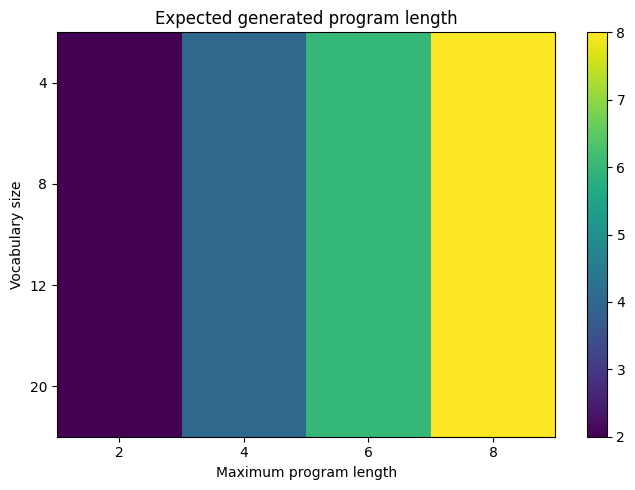

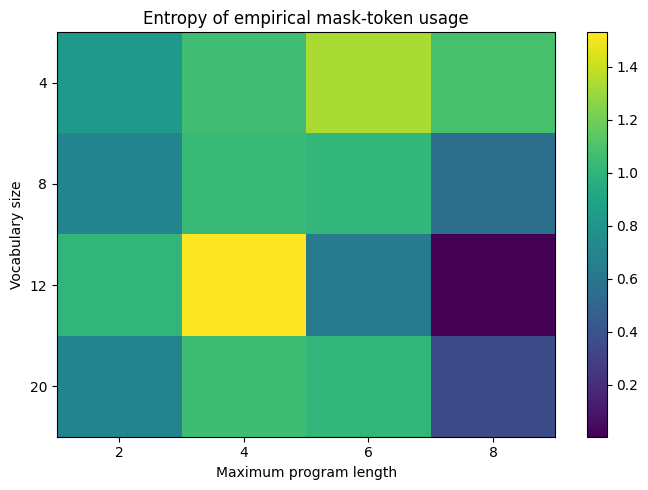

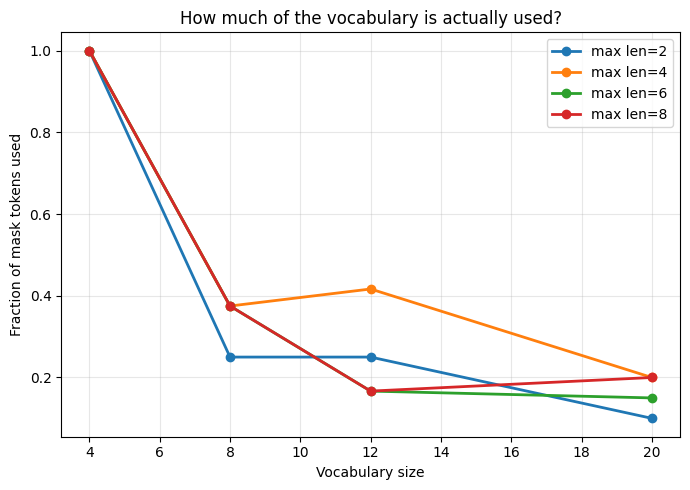

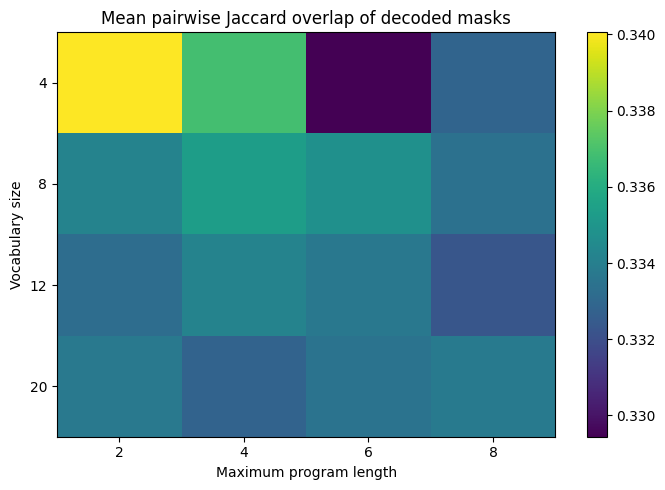


Best model: num_masks=12, max_steps=4


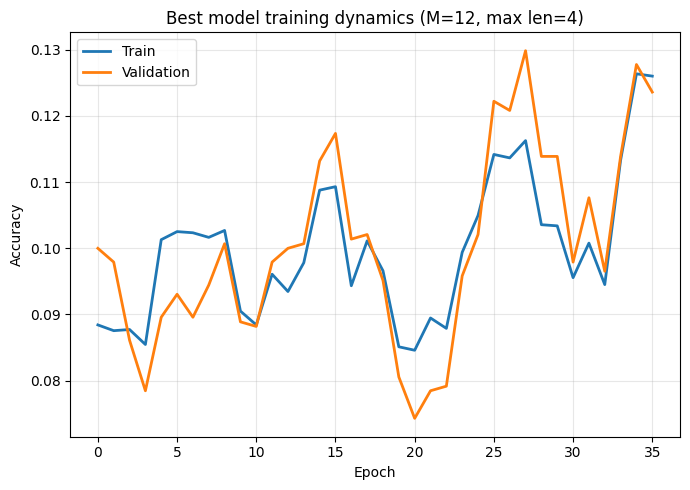

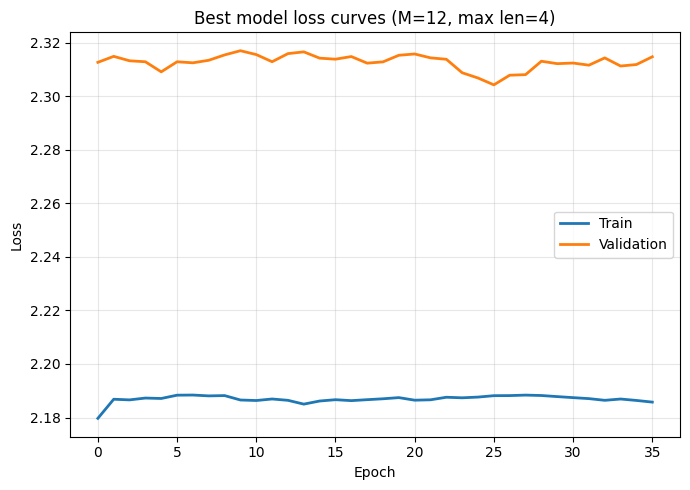

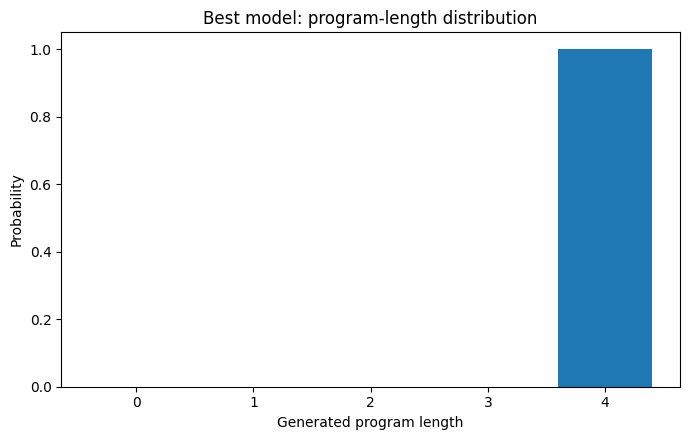

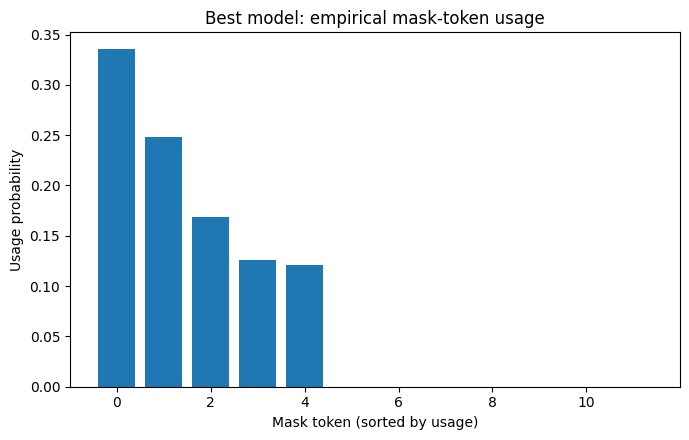

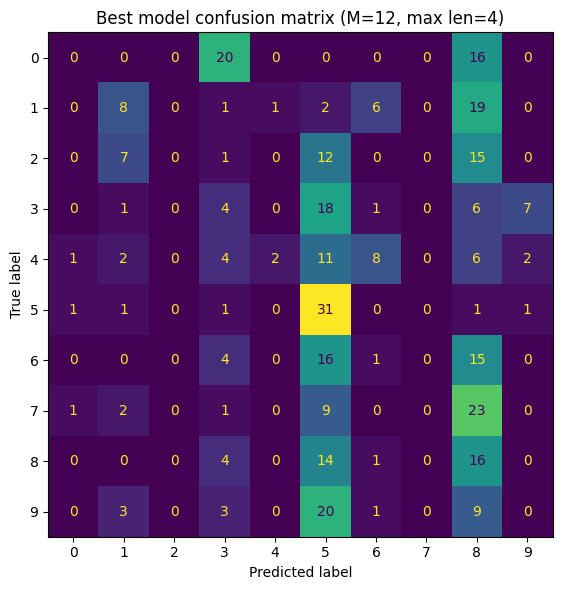

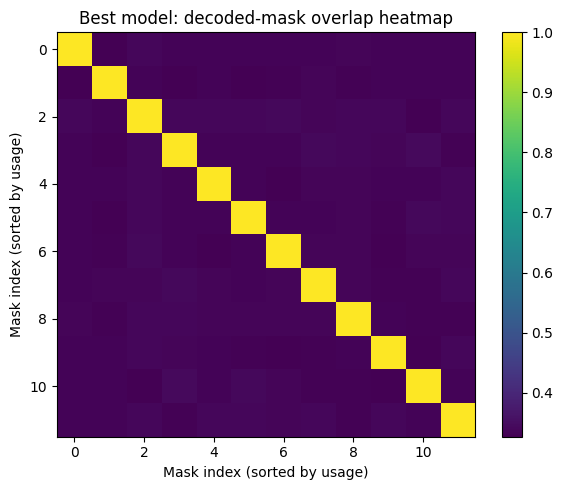

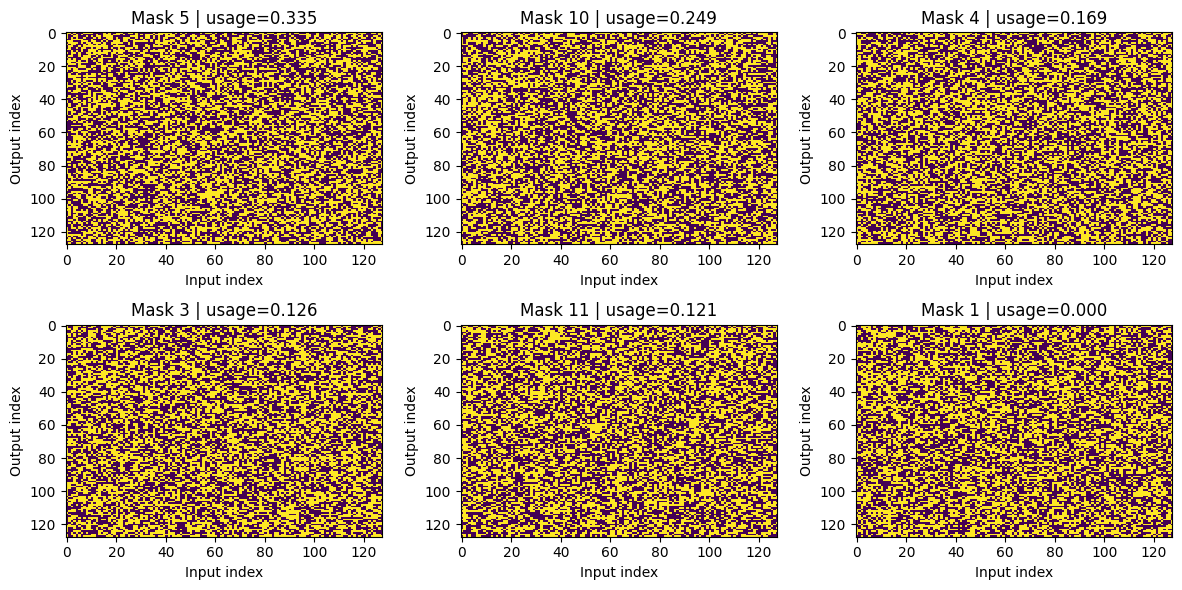

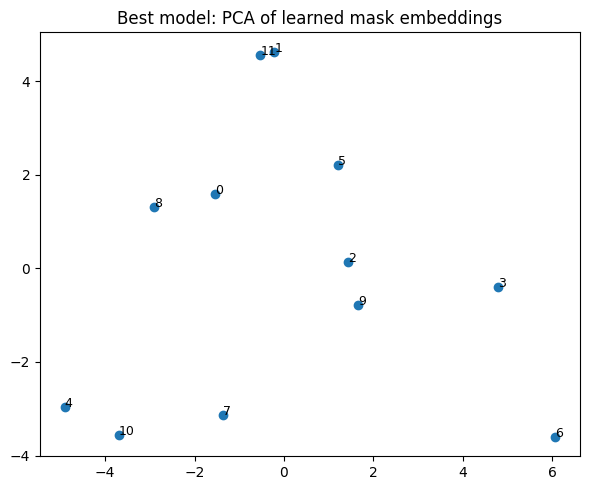

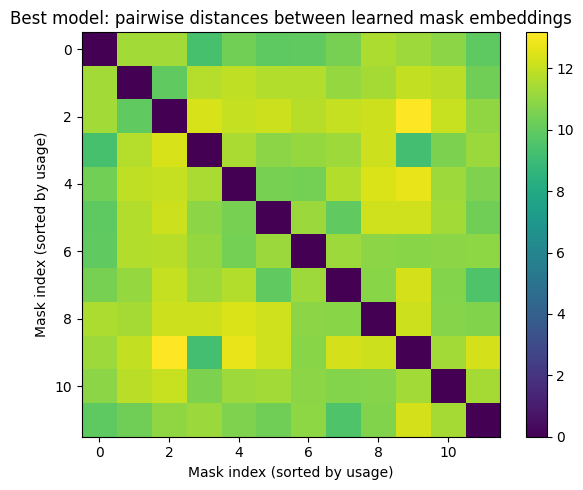


Most common generated programs for the best model:
 154 : <START> M4 M5 M3 M10
 119 : <START> M5 M11 M5 M10
  55 : <START> M11 M5 M4 M10
  27 : <START> M5 M3 M4 M10
   3 : <START> M4 M5 M4 M10
   1 : <START> M5 M5 M3 M5
   1 : <START> M4 M5 M5 M5

Compact sweep summary:
M= 4, max_steps= 2 | test acc=0.0944 | expected len=2.000 | token entropy=0.820 | used tokens=4/4 | mean overlap=0.340
M= 4, max_steps= 4 | test acc=0.1444 | expected len=4.000 | token entropy=1.064 | used tokens=4/4 | mean overlap=0.337
M= 4, max_steps= 6 | test acc=0.1000 | expected len=6.000 | token entropy=1.337 | used tokens=4/4 | mean overlap=0.329
M= 4, max_steps= 8 | test acc=0.1000 | expected len=8.000 | token entropy=1.085 | used tokens=4/4 | mean overlap=0.333
M= 8, max_steps= 2 | test acc=0.1083 | expected len=2.000 | token entropy=0.693 | used tokens=2/8 | mean overlap=0.334
M= 8, max_steps= 4 | test acc=0.1167 | expected len=4.000 | token entropy=1.039 | used tokens=3/8 | mean overlap=0.335
M= 8, max_step

In [ ]:
# ============================================================
# Colab block:
#   1) Pretrain an input autoencoder x <-> h
#   2) Pretrain a frozen readout h -> y, plus optional lift y -> h
#   3) Freeze those interface maps
#   4) Train a transformer mask-program model in the frozen thought space
#
# Assumes these are already defined in a previous cell:
#   - signed_kaiming_constant_
#   - GetSubnet
# ============================================================

import copy, random, math
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# Device / seed
# ============================================================
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)


# ============================================================
# Dataset
# ============================================================
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

batch_size = 128
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=batch_size, shuffle=False)


# ============================================================
# Helpers
# ============================================================
def smooth(x, k=5):
    x = np.asarray(x, dtype=float)
    if len(x) < k:
        return x
    return np.convolve(x, np.ones(k) / k, mode='valid')

def jaccard(A, B):
    A = A > 0.5
    B = B > 0.5
    union = np.logical_or(A, B).sum()
    if union == 0:
        return 1.0
    return np.logical_and(A, B).sum() / union

def empirical_entropy(counts, eps=1e-12):
    counts = np.asarray(counts, dtype=float)
    s = counts.sum()
    if s <= 0:
        return 0.0
    p = counts / s
    return float(-(p * np.log(p + eps)).sum())

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def token_sequence_to_string(seq, num_masks, start_id, end_id):
    pieces = []
    for t in seq:
        if t == start_id:
            pieces.append("<START>")
        elif t == end_id:
            pieces.append("<END>")
        else:
            pieces.append(f"M{t}")
    return " ".join(pieces)


# ============================================================
# Stage 1: input autoencoder x <-> h
# ============================================================
class InputAutoencoder(nn.Module):
    def __init__(self, in_size=64, hidden_size=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_size, hidden_size),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_size, in_size)
        )

    def forward(self, x):
        h = self.encoder(x)
        xhat = self.decoder(h)
        return xhat


def train_input_autoencoder(model, train_loader, val_loader, epochs=80, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_state = None
    best_val = float("inf")
    hist = {"train_loss": [], "val_loss": []}

    for ep in range(epochs):
        model.train()
        total = 0.0
        n = 0
        for x, _ in train_loader:
            x = x.to(device)
            opt.zero_grad()
            xhat = model(x)
            loss = F.mse_loss(xhat, x)
            loss.backward()
            opt.step()
            total += loss.item() * x.size(0)
            n += x.size(0)

        train_loss = total / n

        model.eval()
        total = 0.0
        n = 0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                xhat = model(x)
                loss = F.mse_loss(xhat, x)
                total += loss.item() * x.size(0)
                n += x.size(0)
        val_loss = total / n

        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())

        if ep == 0 or (ep + 1) % 20 == 0 or ep == epochs - 1:
            print(f"[AE1] epoch {ep+1:03d} | train recon={train_loss:.5f} | val recon={val_loss:.5f}")

    model.load_state_dict(best_state)
    return model, hist


# ============================================================
# Stage 2: readout h -> y and optional lift y -> h
# ============================================================
class ThoughtReadoutWithLift(nn.Module):
    """
    readout: h -> logits
    lift: logits -> h
    We train:
      - cross-entropy on readout
      - cycle consistency h -> logits -> h
    """
    def __init__(self, hidden_size=128, out_size=10):
        super().__init__()
        self.readout = nn.Linear(hidden_size, out_size)
        self.lift = nn.Sequential(
            nn.Linear(out_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size)
        )

    def forward(self, h):
        logits = self.readout(h)
        hrec = self.lift(logits)
        return logits, hrec


@torch.no_grad()
def eval_readout(read_model, encoder, loader):
    read_model.eval()
    encoder.eval()
    total = 0
    correct = 0
    ce_total = 0.0
    mse_total = 0.0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        h = encoder(x)
        logits, hrec = read_model(h)
        ce = F.cross_entropy(logits, y)
        mse = F.mse_loss(hrec, h)
        preds = logits.argmax(dim=1)
        total += x.size(0)
        correct += (preds == y).sum().item()
        ce_total += ce.item() * x.size(0)
        mse_total += mse.item() * x.size(0)
    return {
        "acc": correct / total,
        "ce": ce_total / total,
        "mse": mse_total / total
    }


def train_readout_with_lift(read_model, frozen_encoder, train_loader, val_loader, epochs=80, lr=1e-3, lambda_cycle=0.2):
    read_model.to(device)
    frozen_encoder.to(device)
    frozen_encoder.eval()
    for p in frozen_encoder.parameters():
        p.requires_grad_(False)

    opt = torch.optim.Adam(read_model.parameters(), lr=lr)
    best_state = None
    best_val_acc = -1.0
    hist = {"train_acc": [], "val_acc": [], "train_ce": [], "val_ce": [], "train_mse": [], "val_mse": []}

    for ep in range(epochs):
        read_model.train()
        total = 0
        correct = 0
        ce_total = 0.0
        mse_total = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            with torch.no_grad():
                h = frozen_encoder(x)

            opt.zero_grad()
            logits, hrec = read_model(h)
            ce = F.cross_entropy(logits, y)
            mse = F.mse_loss(hrec, h)
            loss = ce + lambda_cycle * mse
            loss.backward()
            opt.step()

            preds = logits.argmax(dim=1)
            total += x.size(0)
            correct += (preds == y).sum().item()
            ce_total += ce.item() * x.size(0)
            mse_total += mse.item() * x.size(0)

        train_acc = correct / total
        train_ce = ce_total / total
        train_mse = mse_total / total

        val_stats = eval_readout(read_model, frozen_encoder, val_loader)

        hist["train_acc"].append(train_acc)
        hist["val_acc"].append(val_stats["acc"])
        hist["train_ce"].append(train_ce)
        hist["val_ce"].append(val_stats["ce"])
        hist["train_mse"].append(train_mse)
        hist["val_mse"].append(val_stats["mse"])

        if val_stats["acc"] > best_val_acc:
            best_val_acc = val_stats["acc"]
            best_state = copy.deepcopy(read_model.state_dict())

        if ep == 0 or (ep + 1) % 20 == 0 or ep == epochs - 1:
            print(
                f"[READOUT] epoch {ep+1:03d} | "
                f"train acc={train_acc:.4f} | val acc={val_stats['acc']:.4f} | "
                f"train mse={train_mse:.5f} | val mse={val_stats['mse']:.5f}"
            )

    read_model.load_state_dict(best_state)
    return read_model, hist


# ============================================================
# Stage 3: learned mask vocabulary
# ============================================================
class LearnedMaskVocabularyLayer(nn.Module):
    def __init__(self, features, num_masks, mask_embed_dim=64, k=0.5):
        super().__init__()
        self.features = features
        self.num_masks = num_masks
        self.mask_embed_dim = mask_embed_dim
        self.k = k

        self.weight = nn.Parameter(torch.empty(features, features), requires_grad=False)
        signed_kaiming_constant_(self.weight)

        self.bias = nn.Parameter(torch.zeros(features), requires_grad=False)

        self.mask_embeddings = nn.Embedding(num_masks, mask_embed_dim)

        self.weight_score_decoder = nn.Sequential(
            nn.Linear(mask_embed_dim, mask_embed_dim),
            nn.ReLU(),
            nn.Linear(mask_embed_dim, features * (2 * features))
        )

        self.bias_score_decoder = nn.Sequential(
            nn.Linear(mask_embed_dim, mask_embed_dim),
            nn.ReLU(),
            nn.Linear(mask_embed_dim, 2 * features)
        )

    def all_decoded_scores(self):
        token_ids = torch.arange(self.num_masks, device=self.weight.device)
        emb = self.mask_embeddings(token_ids)

        w_scores = self.weight_score_decoder(emb)
        w_scores = w_scores.view(self.num_masks, self.features, 2 * self.features)

        b_scores = self.bias_score_decoder(emb)
        b_scores = b_scores.view(self.num_masks, 2, self.features)

        return w_scores, b_scores

    def all_masked_params(self):
        weight_scores, bias_scores = self.all_decoded_scores()

        Ws = []
        bs = []
        for m in range(self.num_masks):
            mask = GetSubnet.apply(weight_scores[m].abs(), self.k)
            Wm = self.weight * mask[:, :self.features]

            bmask = GetSubnet.apply(bias_scores[m].abs(), self.k)
            bm = self.bias * bmask[0, :self.features]

            Ws.append(Wm)
            bs.append(bm)

        W_all = torch.stack(Ws, dim=0)
        b_all = torch.stack(bs, dim=0)
        return W_all, b_all

    def forward(self, h, token_weights):
        W_all, b_all = self.all_masked_params()
        W_batch = torch.einsum('bm,mij->bij', token_weights, W_all)
        b_batch = torch.einsum('bm,mj->bj', token_weights, b_all)
        return torch.einsum('bij,bj->bi', W_batch, h) + b_batch

    def decoded_mask_diversity_loss(self):
        weight_scores, _ = self.all_decoded_scores()
        M = weight_scores.shape[0]
        flat = weight_scores.reshape(M, -1)
        flat = F.normalize(flat, dim=1)
        G = flat @ flat.T
        eye = torch.eye(M, device=G.device)
        offdiag = G * (1.0 - eye)
        return (offdiag ** 2).sum() / max(M * (M - 1), 1)

    @torch.no_grad()
    def get_mask(self, idx):
        weight_scores, _ = self.all_decoded_scores()
        mask = GetSubnet.apply(weight_scores[idx].abs(), self.k)
        return mask[:, :self.features].detach().cpu().numpy()


# ============================================================
# Transformer policy
# ============================================================
class MaskSequenceTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, ff_mult=4, max_len=16):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_mult * d_model,
            batch_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.out = nn.Linear(d_model, vocab_size)

    def forward(self, token_ids, context_embed):
        B, T = token_ids.shape
        pos = torch.arange(T, device=token_ids.device).unsqueeze(0).expand(B, T)

        x = self.token_emb(token_ids) + self.pos_emb(pos)
        x[:, 0, :] = context_embed + self.pos_emb(pos)[:, 0, :]

        causal_mask = torch.triu(
            torch.ones(T, T, device=token_ids.device, dtype=torch.bool),
            diagonal=1
        )

        z = self.transformer(x, mask=causal_mask)
        return self.out(z)


def straight_through_gumbel_one_hot(logits, tau=1.0, eps=1e-20):
    g = -torch.log(-torch.log(torch.rand_like(logits) + eps) + eps)
    probs = torch.softmax((logits + g) / tau, dim=-1)
    idx = probs.argmax(dim=-1)
    y_hard = F.one_hot(idx, num_classes=logits.shape[-1]).float()
    y = y_hard.detach() - probs.detach() + probs
    return y, idx, probs


# ============================================================
# Full program model with frozen interfaces
# ============================================================
class TransformerProgramWithFrozenInterfaces(nn.Module):
    """
    Frozen interfaces:
      - input encoder: A1_in
      - output readout: trained thought->logit map
    Optional fixed-context policy:
      - if dynamic_context=False, policy only sees initial encoded state
      - if dynamic_context=True, policy sees current state at each step
    """
    def __init__(
        self,
        frozen_encoder,
        frozen_readout,
        hidden_size=128,
        out_size=10,
        num_masks=8,
        max_steps=6,
        k=0.5,
        d_model=128,
        nhead=4,
        num_layers=2,
        mask_embed_dim=64,
        dynamic_context=False
    ):
        super().__init__()

        self.encoder = frozen_encoder
        self.readout = frozen_readout
        for p in self.encoder.parameters():
            p.requires_grad_(False)
        for p in self.readout.parameters():
            p.requires_grad_(False)

        self.num_masks = num_masks
        self.max_steps = max_steps
        self.end_id = num_masks
        self.start_id = num_masks + 1
        self.vocab_size = num_masks + 2
        self.dynamic_context = dynamic_context

        self.act = nn.ReLU()
        self.vocab_layer = LearnedMaskVocabularyLayer(
            hidden_size,
            num_masks,
            mask_embed_dim=mask_embed_dim,
            k=k
        )
        self.context_proj = nn.Linear(hidden_size, d_model)
        self.policy = MaskSequenceTransformer(
            vocab_size=self.vocab_size,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            max_len=max_steps + 1
        )

        # diagnostics / aux losses
        self.token_usage = None
        self.seq_len_hist = None
        self.route_entropy = None
        self.generated_sequences = None
        self.token_usage_entropy_loss = None
        self.mask_diversity_loss = None

    def forward(self, x, tau=1.0):
        with torch.no_grad():
            h = self.encoder(x)

        B = h.size(0)
        active = torch.ones(B, dtype=torch.bool, device=h.device)

        initial_context = self.context_proj(h)

        token_counts = torch.zeros(self.num_masks, device=h.device)
        seq_len = torch.zeros(B, dtype=torch.long, device=h.device)
        generated_tokens = [[self.start_id] for _ in range(B)]
        prefix_tokens = torch.full((B, 1), self.start_id, dtype=torch.long, device=h.device)

        entropy_accum = 0.0
        entropy_batches = 0
        all_mask_probs = []

        for step in range(self.max_steps):
            if not torch.any(active):
                break

            active_idx = torch.where(active)[0]
            prefix_active = prefix_tokens[active_idx]

            if self.dynamic_context:
                context_active = self.context_proj(h[active_idx])
            else:
                context_active = initial_context[active_idx]

            logits_full = self.policy(prefix_active, context_active)
            logits_next = logits_full[:, -1, :]

            if self.training:
                route_st, choice, probs = straight_through_gumbel_one_hot(logits_next, tau=tau)
            else:
                probs = torch.softmax(logits_next, dim=-1)
                choice = logits_next.argmax(dim=1)
                route_st = F.one_hot(choice, num_classes=self.vocab_size).float()

            entropy_accum += float((-(probs * torch.log(probs + 1e-12)).sum(dim=1)).mean().detach().cpu())
            entropy_batches += 1
            all_mask_probs.append(probs[:, :self.num_masks])

            halt = (choice == self.end_id)
            go = torch.logical_not(halt)

            append_col = torch.full((B, 1), self.end_id, dtype=torch.long, device=h.device)
            append_col[active_idx, 0] = choice
            prefix_tokens = torch.cat([prefix_tokens, append_col], dim=1)

            for loc, glob in enumerate(active_idx.tolist()):
                generated_tokens[glob].append(int(choice[loc].item()))

            h_next = h.clone()
            if torch.any(go):
                go_local = torch.where(go)[0]
                go_global = active_idx[go_local]

                h_go = h[go_global]
                mask_weights = route_st[go_local, :self.num_masks]
                h_new = self.vocab_layer(h_go, mask_weights)
                h_new = self.act(h_new)
                h_next[go_global] = h_new

                choice_go = choice[go_local]
                for m in range(self.num_masks):
                    token_counts[m] += (choice_go == m).sum()

                seq_len[go_global] += 1

            h = h_next

            next_active = torch.zeros_like(active)
            if torch.any(go):
                next_active[go_global] = True
            active = next_active

        self.generated_sequences = generated_tokens
        self.seq_len_hist = np.bincount(seq_len.detach().cpu().numpy(), minlength=self.max_steps + 1)
        self.token_usage = token_counts.detach().cpu().numpy()
        self.route_entropy = entropy_accum / max(entropy_batches, 1)

        if len(all_mask_probs) > 0:
            P = torch.cat(all_mask_probs, dim=0)
            mean_p = P.mean(dim=0)
            self.token_usage_entropy_loss = torch.sum(mean_p * torch.log(mean_p + 1e-12))
        else:
            self.token_usage_entropy_loss = torch.tensor(0.0, device=x.device)

        self.mask_diversity_loss = self.vocab_layer.decoded_mask_diversity_loss()

        with torch.no_grad():
            logits = self.readout(h)
        return logits


# ============================================================
# Program model evaluation / training
# ============================================================
@torch.no_grad()
def evaluate_program(model, loader, collect_stats=False):
    model.eval()
    total = 0
    correct = 0
    total_loss = 0.0

    token_usage = None
    seq_len_hist = None
    entropies = []
    y_true = []
    y_pred = []
    all_sequences = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = F.cross_entropy(logits, y)
        preds = logits.argmax(dim=1)

        total += x.size(0)
        correct += (preds == y).sum().item()
        total_loss += loss.item() * x.size(0)

        if collect_stats:
            if token_usage is None:
                token_usage = model.token_usage.copy()
                seq_len_hist = model.seq_len_hist.copy()
            else:
                token_usage += model.token_usage
                seq_len_hist += model.seq_len_hist

            entropies.append(model.route_entropy)
            all_sequences.extend(model.generated_sequences)
            y_true.append(y.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    out = {"acc": correct / total, "loss": total_loss / total}
    if collect_stats:
        out["token_usage"] = token_usage
        out["seq_len_hist"] = seq_len_hist
        out["route_entropy"] = float(np.mean(entropies)) if entropies else 0.0
        out["y_true"] = np.concatenate(y_true) if len(y_true) else None
        out["y_pred"] = np.concatenate(y_pred) if len(y_pred) else None
        out["sequences"] = all_sequences
    return out


def train_program(
    model,
    train_loader,
    val_loader,
    epochs=40,
    lr=1e-3,
    lambda_usage=0.05,
    lambda_mask_div=0.01
):
    model.to(device)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

    history = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": [],
        "tau": [],
        "usage_reg": [],
        "mask_div_reg": []
    }

    best_state = None
    best_val_acc = -1.0

    for ep in range(epochs):
        model.train()
        tau = max(0.30, 1.0 * (0.97 ** ep))
        total_loss = 0.0
        total_usage = 0.0
        total_mask_div = 0.0
        n_seen = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            opt.zero_grad()
            logits = model(x, tau=tau)
            cls_loss = F.cross_entropy(logits, y)
            usage_reg = model.token_usage_entropy_loss
            mask_div_reg = model.mask_diversity_loss
            loss = cls_loss + lambda_usage * usage_reg + lambda_mask_div * mask_div_reg
            loss.backward()
            opt.step()

            total_loss += loss.item() * x.size(0)
            total_usage += float(usage_reg.detach().cpu()) * x.size(0)
            total_mask_div += float(mask_div_reg.detach().cpu()) * x.size(0)
            n_seen += x.size(0)

        train_stats = evaluate_program(model, train_loader, collect_stats=False)
        val_stats = evaluate_program(model, val_loader, collect_stats=False)

        history["train_acc"].append(train_stats["acc"])
        history["val_acc"].append(val_stats["acc"])
        history["train_loss"].append(total_loss / n_seen)
        history["val_loss"].append(val_stats["loss"])
        history["tau"].append(tau)
        history["usage_reg"].append(total_usage / n_seen)
        history["mask_div_reg"].append(total_mask_div / n_seen)

        if val_stats["acc"] > best_val_acc:
            best_val_acc = val_stats["acc"]
            best_state = copy.deepcopy(model.state_dict())

        if ep == 0 or (ep + 1) % 10 == 0 or ep == epochs - 1:
            print(
                f"[PROGRAM] epoch {ep+1:03d} | tau={tau:.3f} | "
                f"train acc={train_stats['acc']:.4f} | val acc={val_stats['acc']:.4f} | "
                f"usage reg={total_usage/n_seen:.4f} | mask div={total_mask_div/n_seen:.4f}"
            )

    model.load_state_dict(best_state)
    return model, history


# ============================================================
# Pretrain interfaces
# ============================================================
hidden_size = 128
out_size = 10

ae1 = InputAutoencoder(in_size=64, hidden_size=hidden_size)
ae1, ae1_hist = train_input_autoencoder(ae1, train_loader, val_loader, epochs=80, lr=1e-3)

read_model = ThoughtReadoutWithLift(hidden_size=hidden_size, out_size=out_size)
read_model, read_hist = train_readout_with_lift(
    read_model,
    frozen_encoder=ae1.encoder,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=80,
    lr=1e-3,
    lambda_cycle=0.2
)

test_read_stats = eval_readout(read_model, ae1.encoder, test_loader)
print("\nFrozen interface quality:")
print(test_read_stats)


# ============================================================
# Sweep over vocabulary size and max program length
# ============================================================
mask_grid = [4, 8, 12, 20]
step_grid = [2, 4, 6, 8]

epochs_program = 40
k = 0.5
mask_embed_dim = 64
dynamic_context = False   # set True if you want current-state-inside-policy version

results = {}
best_key = None
best_val_acc = -1.0
best_model = None
best_history = None
best_eval = None

for num_masks in mask_grid:
    for max_steps in step_grid:
        print("\n" + "=" * 72)
        print(f"Training config: num_masks={num_masks}, max_steps={max_steps}")
        print("=" * 72)

        model = TransformerProgramWithFrozenInterfaces(
            frozen_encoder=copy.deepcopy(ae1.encoder),
            frozen_readout=copy.deepcopy(read_model.readout),
            hidden_size=hidden_size,
            out_size=out_size,
            num_masks=num_masks,
            max_steps=max_steps,
            k=k,
            d_model=128,
            nhead=4,
            num_layers=2,
            mask_embed_dim=mask_embed_dim,
            dynamic_context=dynamic_context
        )

        total_params, trainable_params = count_parameters(model)
        print(f"total params={total_params}, trainable params={trainable_params}")

        model, history = train_program(
            model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=epochs_program,
            lr=1e-3,
            lambda_usage=0.05,
            lambda_mask_div=0.01
        )

        val_eval = evaluate_program(model, val_loader, collect_stats=True)
        test_eval = evaluate_program(model, test_loader, collect_stats=True)

        token_usage = test_eval["token_usage"]
        seq_len_hist = test_eval["seq_len_hist"]

        seq_lengths = np.arange(len(seq_len_hist))
        expected_seq_len = float((seq_lengths * seq_len_hist).sum() / max(seq_len_hist.sum(), 1))
        token_entropy = empirical_entropy(token_usage)
        used_token_fraction = float((token_usage > 0).sum() / len(token_usage))

        masks = [model.vocab_layer.get_mask(i) for i in range(model.num_masks)]
        overlap = np.zeros((model.num_masks, model.num_masks), dtype=float)
        for i in range(model.num_masks):
            for j in range(model.num_masks):
                overlap[i, j] = jaccard(masks[i], masks[j])

        offdiag = overlap[~np.eye(model.num_masks, dtype=bool)]
        mean_offdiag_overlap = float(offdiag.mean()) if len(offdiag) else 1.0

        seq_counter = Counter(tuple(seq) for seq in test_eval["sequences"])
        common_sequences = seq_counter.most_common(10)

        key = (num_masks, max_steps)
        results[key] = {
            "history": history,
            "val_acc": val_eval["acc"],
            "test_acc": test_eval["acc"],
            "val_loss": val_eval["loss"],
            "test_loss": test_eval["loss"],
            "token_usage": token_usage,
            "seq_len_hist": seq_len_hist,
            "route_entropy": test_eval["route_entropy"],
            "expected_seq_len": expected_seq_len,
            "token_entropy": token_entropy,
            "used_token_fraction": used_token_fraction,
            "mean_offdiag_overlap": mean_offdiag_overlap,
            "overlap": overlap,
            "confusion_true": test_eval["y_true"],
            "confusion_pred": test_eval["y_pred"],
            "common_sequences": common_sequences,
            "sequences": test_eval["sequences"],
            "num_masks": num_masks,
            "max_steps": max_steps,
            "model_state": copy.deepcopy(model.state_dict())
        }

        print(
            f"val acc={val_eval['acc']:.4f} | test acc={test_eval['acc']:.4f} | "
            f"expected len={expected_seq_len:.3f} | "
            f"token entropy={token_entropy:.3f} | "
            f"used tokens={int((token_usage > 0).sum())}/{len(token_usage)}"
        )

        if val_eval["acc"] > best_val_acc:
            best_val_acc = val_eval["acc"]
            best_key = key
            best_model = TransformerProgramWithFrozenInterfaces(
                frozen_encoder=copy.deepcopy(ae1.encoder),
                frozen_readout=copy.deepcopy(read_model.readout),
                hidden_size=hidden_size,
                out_size=out_size,
                num_masks=num_masks,
                max_steps=max_steps,
                k=k,
                d_model=128,
                nhead=4,
                num_layers=2,
                mask_embed_dim=mask_embed_dim,
                dynamic_context=dynamic_context
            ).to(device)
            best_model.load_state_dict(copy.deepcopy(model.state_dict()))
            best_history = copy.deepcopy(history)
            best_eval = copy.deepcopy(results[key])

print("\nBest configuration:", best_key, "with val acc =", best_val_acc)


# ============================================================
# Convert sweep results to arrays
# ============================================================
test_acc_grid = np.zeros((len(mask_grid), len(step_grid)))
expected_len_grid = np.zeros((len(mask_grid), len(step_grid)))
token_entropy_grid = np.zeros((len(mask_grid), len(step_grid)))
used_token_fraction_grid = np.zeros((len(mask_grid), len(step_grid)))
overlap_grid = np.zeros((len(mask_grid), len(step_grid)))

for i, num_masks in enumerate(mask_grid):
    for j, max_steps in enumerate(step_grid):
        r = results[(num_masks, max_steps)]
        test_acc_grid[i, j] = r["test_acc"]
        expected_len_grid[i, j] = r["expected_seq_len"]
        token_entropy_grid[i, j] = r["token_entropy"]
        used_token_fraction_grid[i, j] = r["used_token_fraction"]
        overlap_grid[i, j] = r["mean_offdiag_overlap"]


# ============================================================
# Figures for pretrained interfaces
# ============================================================
plt.figure(figsize=(7, 5))
plt.plot(smooth(ae1_hist["train_loss"], 5), linewidth=2, label="Train")
plt.plot(smooth(ae1_hist["val_loss"], 5), linewidth=2, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss")
plt.title("Input autoencoder training")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(smooth(read_hist["train_acc"], 5), linewidth=2, label="Train")
plt.plot(smooth(read_hist["val_acc"], 5), linewidth=2, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Frozen thought-space readout training")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Sweep figures
# ============================================================
plt.figure(figsize=(7, 5))
for i, num_masks in enumerate(mask_grid):
    plt.plot(step_grid, test_acc_grid[i], marker='o', linewidth=2, label=f"M={num_masks}")
plt.xlabel("Maximum program length")
plt.ylabel("Test accuracy")
plt.title("Frozen-interface transformer program model: test accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
im = plt.imshow(test_acc_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(step_grid)), step_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum program length")
plt.ylabel("Vocabulary size")
plt.title("Test accuracy heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
im = plt.imshow(expected_len_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(step_grid)), step_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum program length")
plt.ylabel("Vocabulary size")
plt.title("Expected generated program length")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
im = plt.imshow(token_entropy_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(step_grid)), step_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum program length")
plt.ylabel("Vocabulary size")
plt.title("Entropy of empirical mask-token usage")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
for j, max_steps in enumerate(step_grid):
    vals = [used_token_fraction_grid[i, j] for i in range(len(mask_grid))]
    plt.plot(mask_grid, vals, marker='o', linewidth=2, label=f"max len={max_steps}")
plt.xlabel("Vocabulary size")
plt.ylabel("Fraction of mask tokens used")
plt.title("How much of the vocabulary is actually used?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
im = plt.imshow(overlap_grid, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(step_grid)), step_grid)
plt.yticks(range(len(mask_grid)), mask_grid)
plt.xlabel("Maximum program length")
plt.ylabel("Vocabulary size")
plt.title("Mean pairwise Jaccard overlap of decoded masks")
plt.tight_layout()
plt.show()


# ============================================================
# Best-model graphics
# ============================================================
best_num_masks, best_max_steps = best_key
print(f"\nBest model: num_masks={best_num_masks}, max_steps={best_max_steps}")

best_masks = [best_model.vocab_layer.get_mask(i) for i in range(best_model.num_masks)]
best_token_usage = best_eval["token_usage"].astype(float)
best_token_probs = best_token_usage / max(best_token_usage.sum(), 1.0)
best_order = np.argsort(-best_token_probs)

plt.figure(figsize=(7, 5))
plt.plot(smooth(best_history["train_acc"], 5), linewidth=2, label="Train")
plt.plot(smooth(best_history["val_acc"], 5), linewidth=2, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Best model training dynamics (M={best_num_masks}, max len={best_max_steps})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(smooth(best_history["train_loss"], 5), linewidth=2, label="Train")
plt.plot(smooth(best_history["val_loss"], 5), linewidth=2, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Best model loss curves (M={best_num_masks}, max len={best_max_steps})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

seq_len_hist = best_eval["seq_len_hist"].astype(float)
seq_len_probs = seq_len_hist / max(seq_len_hist.sum(), 1.0)

plt.figure(figsize=(7, 4.5))
plt.bar(np.arange(len(seq_len_probs)), seq_len_probs)
plt.xlabel("Generated program length")
plt.ylabel("Probability")
plt.title("Best model: program-length distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.bar(np.arange(len(best_token_probs)), best_token_probs[best_order])
plt.xlabel("Mask token (sorted by usage)")
plt.ylabel("Usage probability")
plt.title("Best model: empirical mask-token usage")
plt.tight_layout()
plt.show()

cm = confusion_matrix(best_eval["confusion_true"], best_eval["confusion_pred"])
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Best model confusion matrix (M={best_num_masks}, max len={best_max_steps})")
plt.tight_layout()
plt.show()

best_overlap = best_eval["overlap"]
plt.figure(figsize=(6, 5))
im = plt.imshow(best_overlap[best_order][:, best_order], aspect='auto')
plt.colorbar(im)
plt.xlabel("Mask index (sorted by usage)")
plt.ylabel("Mask index (sorted by usage)")
plt.title("Best model: decoded-mask overlap heatmap")
plt.tight_layout()
plt.show()

num_show = min(6, best_num_masks)
top_mask_indices = best_order[:num_show]
fig, axes = plt.subplots(2, int(np.ceil(num_show / 2)), figsize=(12, 6))
axes = np.array(axes).reshape(-1)

for ax, idx in zip(axes, top_mask_indices):
    ax.imshow(best_masks[idx], aspect='auto', interpolation='nearest')
    ax.set_title(f"Mask {idx} | usage={best_token_probs[idx]:.3f}")
    ax.set_xlabel("Input index")
    ax.set_ylabel("Output index")

for ax in axes[num_show:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

with torch.no_grad():
    E = best_model.vocab_layer.mask_embeddings.weight.detach().cpu().numpy()

Z = PCA(n_components=2).fit_transform(E)
plt.figure(figsize=(6, 5))
plt.scatter(Z[:, 0], Z[:, 1])
for i in range(len(Z)):
    plt.text(Z[i, 0], Z[i, 1], str(i), fontsize=9)
plt.title("Best model: PCA of learned mask embeddings")
plt.tight_layout()
plt.show()

D = np.sqrt(((E[:, None, :] - E[None, :, :]) ** 2).sum(axis=-1))
plt.figure(figsize=(6, 5))
im = plt.imshow(D[best_order][:, best_order], aspect='auto')
plt.colorbar(im)
plt.xlabel("Mask index (sorted by usage)")
plt.ylabel("Mask index (sorted by usage)")
plt.title("Best model: pairwise distances between learned mask embeddings")
plt.tight_layout()
plt.show()

print("\nMost common generated programs for the best model:")
for seq, cnt in best_eval["common_sequences"][:10]:
    print(f"{cnt:>4} : {token_sequence_to_string(seq, best_num_masks, best_model.start_id, best_model.end_id)}")

print("\nCompact sweep summary:")
for num_masks in mask_grid:
    for max_steps in step_grid:
        r = results[(num_masks, max_steps)]
        print(
            f"M={num_masks:>2}, max_steps={max_steps:>2} | "
            f"test acc={r['test_acc']:.4f} | "
            f"expected len={r['expected_seq_len']:.3f} | "
            f"token entropy={r['token_entropy']:.3f} | "
            f"used tokens={int((r['token_usage'] > 0).sum())}/{len(r['token_usage'])} | "
            f"mean overlap={r['mean_offdiag_overlap']:.3f}"
        )